## County Own-Source Revenue Forecasting: A Data-Driven Modelling Framework

County governments depend on **own-source revenue (OSR)** to support service delivery, strengthen fiscal autonomy, and improve budget credibility. Yet previius county OSR forecasting was built on simple point elasticities that assume revenue moves proportionally with Gross County Product (GCP). In practice, that assumption is weak. County revenues are shaped not only by economic activity, but also by administrative capacity, enforcement effort, tariff design, and the structure of local revenue handles.

This notebook develops a data-driven forecasting framework that moves beyond mechanical elasticity-based forecasting. It begins by diagnosing county revenue structures using machine-learning tools, then evaluates whether economic linkage is meaningful, and finally selects the best county-specific forecasting model from a transparent set of simple alternatives. The objective is not modelling complexity for its own sake, but a forecasting workflow that is empirically grounded, operationally practical, and usable for county budgeting and medium-term fiscal planning.

## 0. Environment Setup and Libraries

This section initializes the analytical environment required for the county OSR modelling framework. It includes core libraries for data handling, visualization, machine learning, and model evaluation.

The workflow combines standard econometric tools with machine learning techniques to support:
- Data preparation and transformation
- Structural diagnostics (clustering and scaling)
- Model estimation and comparison
- Forecast evaluation and interpretation

Optional packages such as `xgboost` and `shap` are included to enable advanced model testing and explainability where needed.

In [1]:
# =========================================================
# 0. Imports
# =========================================================

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Preprocessing and clustering
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans

# Regression and model selection
from sklearn.linear_model import ElasticNetCV

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error

import statsmodels.api as sm

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import shap
import os
import warnings
print('libraries successfully done')

libraries successfully done


## 1. Data Loading and Structuring

The raw dataset contains county-level Own-Source Revenue (OSR) shares by revenue head. Due to the Excel layout, column names are initially misaligned and read as generic labels.

This section restructures the dataset by:
- Extracting the correct header row
- Renaming columns appropriately
- Converting values into numeric format
- Preparing a clean panel dataset for analysis

This step is critical to ensure consistency in subsequent modelling and diagnostics.

In [2]:

df = pd.read_excel("OSR_Per_County 08_12_2025.xlsx")
print(df.head())
print(df.columns)
print(df.dtypes)


    County  Year  Nominal_GCP  Agriculture, forestry and fishing  \
0  Baringo  2017  301404377.0                       19712.969537   
1  Baringo  2018  359321520.0                       19525.041101   
2  Baringo  2019  301663843.0                                NaN   
3  Baringo  2020  205203689.0                       29185.000000   
4  Baringo  2021  253451349.0                       30592.000000   

   Mining and quarrying  Manufacturing  Electricity supply   \
0            139.623657    3825.188145           209.873969   
1            130.817284    4106.420309           114.497942   
2                   NaN            NaN                  NaN   
3            146.000000    4523.000000           132.000000   
4            174.000000    4555.000000           128.000000   

   Water Supply; Waste\nCollection  Construction  \
0                       336.885134   1241.326239   
1                       385.915456   1482.465979   
2                              NaN           NaN   
3   

## 2. Data Cleaning and Harmonization

The dataset is standardized to ensure consistency across counties and variables. Column names are cleaned to remove formatting inconsistencies, and key variables are harmonized to support panel analysis.

The resulting dataset combines:
- County identifiers and time dimension
- Macroeconomic indicators (e.g. Gross County Product)
- Sectoral economic activity
- Detailed Own-Source Revenue (OSR) components

This structure allows the analysis to move beyond aggregate relationships and examine how economic activity and revenue composition interact across counties over time.

In [3]:
# Clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.replace('\n', ' ', regex=False)
      .str.replace(r'\s+', ' ', regex=True)
)

rename_map = {
    'County': 'county',
    'Year': 'year',
    'Nominal_GCP': 'gcp_nominal',
    'Population': 'population',
    'Working Population': 'working_pop',
    'Land (km^2)': 'land_km2',
    'County_revenue': 'osr'   # adjust if slightly different
}

df = df.rename(columns=rename_map)
df.head()


,county,year,gcp_nominal,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Electricity supply,Water Supply; Waste Collection,Construction,Wholesale & Retail Trade; Repair of Motor Vehicle,...,TECHNICAL SERVICES FEES,LIQUOR LICENCES,WEIGHT &MEASURES,APPLICATION FOR SBP/RENEWAL,MARKET STALLS/SLABS,SINGLE BUSINESS PERMITS,MARKET FEES.1,APPLICATION FOR LIQUOR License,CO- OPERATIVES,COMMUNITY WATER SUPPLY ADMINISTRATION FEES
0,Baringo,2017,301404377.0,19712.969537,139.623657,3825.188145,209.873969,336.885134,1241.326239,2059.949446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baringo,2018,359321520.0,19525.041101,130.817284,4106.420309,114.497942,385.915456,1482.465979,2149.242371,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Baringo,2019,301663843.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Baringo,2020,205203689.0,29185.000000,146.000000,4523.000000,132.000000,405.000000,2039.000000,2311.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Baringo,2021,253451349.0,30592.000000,174.000000,4555.000000,128.000000,401.000000,2316.000000,2531.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Feature Engineering for Structural Diagnostics

This section constructs the core analytical variables used to characterize county revenue systems. The objective is to move from raw levels to economically meaningful measures that capture scale, intensity, density, and volatility.

The variables created here support two distinct purposes. First, they allow assessment of the relationship between own-source revenue (OSR) and county economic activity through logs, effective rates, and growth rates. Second, they provide county-level structural features used later in clustering, so that counties can be grouped according to their revenue–economy profiles rather than treated as homogeneous units.

This step is central to the modelling strategy because it translates raw administrative and economic data into the structural indicators that guide model selection.

In [4]:
# =========================================================
# 3. Feature Engineering for Structural Diagnostics
# =========================================================

# 3.1 Remove rows with missing core values
df = df.dropna(subset=["county", "year", "gcp_nominal", "osr", "population", "land_km2"])

# 3.2 Sort panel
df = df.sort_values(["county", "year"]).reset_index(drop=True)

# 3.3 Construct transformed variables
eps = 1e-6

# Logs
df["ln_osr"] = np.log(df["osr"] + eps)
df["ln_gcp"] = np.log(df["gcp_nominal"] + eps)

# Effective rate
df["eff_rate"] = df["osr"] / df["gcp_nominal"]
df["ln_eff_rate"] = np.log(df["eff_rate"] + eps)

# Per capita indicators
df["osr_pc"] = df["osr"] / df["population"]
df["gcp_pc"] = df["gcp_nominal"] / df["population"]

# Density indicators
df["pop_density"] = df["population"] / df["land_km2"]
df["gcp_density"] = df["gcp_nominal"] / df["land_km2"]

# Growth rates
df["ln_osr_lag"] = df.groupby("county")["ln_osr"].shift(1)
df["ln_gcp_lag"] = df.groupby("county")["ln_gcp"].shift(1)

df["dln_osr"] = df["ln_osr"] - df["ln_osr_lag"]
df["dln_gcp"] = df["ln_gcp"] - df["ln_gcp_lag"]

# Quick inspection
df[[
    "county", "year", "osr", "gcp_nominal", "ln_osr", "ln_gcp",
    "eff_rate", "osr_pc", "gcp_pc", "pop_density", "gcp_density",
    "dln_osr", "dln_gcp"
]].head()

,county,year,osr,gcp_nominal,ln_osr,ln_gcp,eff_rate,osr_pc,gcp_pc,pop_density,gcp_density,dln_osr,dln_gcp
0,Baringo,2019,70754.0,301663843.0,11.166964,19.524824,0.000235,0.106116,452.430388,60.745144,27482.949145,NaN,NaN
1,Baringo,2020,75459.0,205203689.0,11.231345,19.139514,0.000368,0.109884,298.818420,62.563044,18694.990070,0.064380,-0.385310
2,Baringo,2021,85220.0,253451349.0,11.352991,19.350682,0.000336,0.121352,360.910194,63.978718,23090.571499,0.121647,0.211169
3,Baringo,2022,93334.0,312102220.0,11.443940,19.558841,0.000299,0.130029,434.807507,65.394300,28433.932801,0.090948,0.208159
4,Bomet,2019,137299.0,201510614.0,11.829916,19.121353,0.000681,0.156790,230.116644,345.999052,79620.140661,NaN,NaN


In [5]:
# =========================================================
#  Build County-Level Structural Features for Clustering
# =========================================================

agg_dict = {
    "ln_osr": "mean",
    "ln_gcp": "mean",
    "eff_rate": "mean",
    "osr_pc": "mean",
    "gcp_pc": "mean",
    "pop_density": "mean",
    "gcp_density": "mean",
    "dln_osr": "std",
    "dln_gcp": "std"
}

# Include revenue composition shares if already created
for col in df.columns:
    if col.startswith("share_"):
        agg_dict[col] = "mean"

county_feats = df.groupby("county").agg(agg_dict).reset_index()

county_feats.head()

,county,ln_osr,ln_gcp,eff_rate,osr_pc,gcp_pc,pop_density,gcp_density,dln_osr,dln_gcp
0,Baringo,11.298810,19.393465,0.000309,0.116845,386.741627,63.170302,24425.610879,0.028658,0.343512
1,Bomet,11.990962,19.143457,0.000785,0.179421,228.748324,357.434905,81831.018610,0.030417,0.143702
2,Bungoma,12.293411,20.679371,0.000229,0.127819,563.449841,567.013211,320116.686812,0.030797,0.223360
3,Busia,11.468448,19.540055,0.000317,0.104313,338.102634,543.776749,184166.782114,0.037119,0.409742
4,Elgeyo_Marakwet,11.677506,18.900946,0.000738,0.248882,344.653599,156.543288,54101.305079,0.107933,0.154280



## 4. Clustering Counties by Revenue–Economy Structure

Counties differ materially in revenue capacity, economic scale, fiscal effort, and volatility. **A single forecasting rule** is therefore unlikely to fit all counties well. To capture this heterogeneity, counties are grouped according to their **underlying revenue–economy structure** rather than treated as homogeneous units.

The clustering is based on **normalized county-level indicators** covering revenue scale, economic size, effective revenue rates, per-capita performance, density, and volatility. K-Means is then used to identify broad structural groupings. The number of clusters is selected using the elbow method, which evaluates how quickly within-cluster variation declines as additional clusters are introduced.

In practical terms, the optimal number of clusters is the point beyond which extra clusters add little explanatory value. For counties, this means identifying a small number of structurally distinct revenue regimes that can guide model choice more credibly than imposing a uniform OSR–GCP relationship across all counties.

C:\Users\hp\anaconda3\envs\cyrus-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


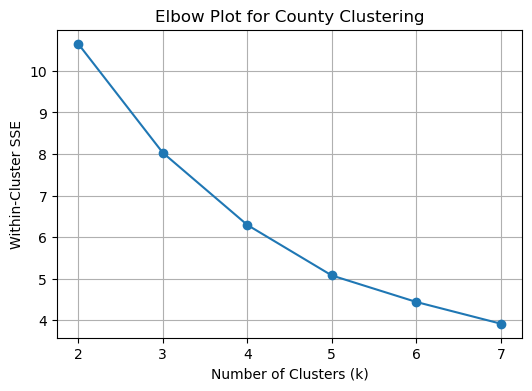

In [6]:
# =========================================================
# 4. Clustering Counties by Revenue–Economy Structure
# =========================================================
import os
import warnings

# Suppress Windows MKL / KMeans warning
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL*")

# 4.1 Prepare feature matrix
features_for_cluster = county_feats.drop(columns=["county"]).fillna(0)

# 4.2 Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features_for_cluster)

# 4.3 Determine optimal number of clusters (Elbow Method)
inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# 4.4 Plot elbow curve
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster SSE")
plt.title("Elbow Plot for County Clustering")
plt.grid(True)
plt.show()

## 4. County Segmentation: Structural Revenue–Economy Profiles

Counties exhibit substantial heterogeneity in both their economic base and revenue performance. To account for this, we group counties into structurally similar clusters based on their revenue capacity, economic scale, fiscal effort, and sectoral composition.

The feature space combines:
- Revenue scale and economic size (log OSR, log GCP)
- Fiscal effort (OSR-to-GCP ratio)
- Per capita and spatial intensity (OSR per capita, GCP per capita, densities)
- Volatility (growth dispersion in OSR and GCP)
- Economic structure (agriculture, industry, and services shares)

All variables are normalised to ensure comparability, and clustering is implemented using K-means.

The number of clusters is fixed at **k = 3**, reflecting a parsimonious segmentation of counties into broad structural groups:
- **High-capacity systems**: large economic base and strong revenue performance
- **Intermediate systems**: moderate capacity with evolving revenue structures
- **Low-capacity systems**: limited economic base and weaker revenue mobilisation

This classification is not purely statistical; it provides an economic partition of counties into distinct regimes. These regimes form the basis for differentiated modelling, allowing subsequent analysis to capture structural differences in revenue behaviour rather than imposing a single national relationship.

## 4.2 Interpretation of County Clusters

The clustering results group counties into three distinct structural categories, reflecting differences in economic capacity, revenue mobilisation, and stability.

**Cluster 1** contains the majority of counties, including Baringo, Bungoma, Busia, Kiambu, Kisumu, Nakuru, Uasin Gishu, and others. These counties exhibit **moderate and relatively balanced performance**, where revenue generation broadly aligns with their economic base. They represent the “typical” fiscal structure—neither highly efficient nor severely constrained. For policy, this group offers the **largest immediate gains from incremental improvements in compliance, administration, and base expansion**, as their systems are already functional but not fully optimized.

**Cluster 2** consists of **Nairobi and Mombasa**, which are clear outliers. These counties combine **high economic density with strong revenue mobilisation**, reflecting urban concentration, diversified economic activity, and more developed administrative systems. They operate at a **high-efficiency equilibrium**, where revenue capacity is already close to its potential. Policy focus here should shift from basic mobilisation to **efficiency, innovation, and sustainability of revenue systems**, including managing congestion, informality, and service demand.

**Cluster 3** includes counties such as West Pokot, Turkana, Mandera, Kitui, and Marsabit. These counties are characterized by **low revenue capacity relative to their economic base, higher volatility, and structural constraints**. In many cases, economic activity is either limited, informal, or difficult to tax. This cluster reflects **structural fiscal vulnerability**, where revenue performance is constrained by geography, economic composition, and administrative reach. Policy interventions must therefore go beyond tax administration to include **economic development, formalization, and targeted institutional strengthening**.

Overall, the clustering confirms that differences in county revenue performance are **structural rather than incidental**. A uniform policy approach is therefore inefficient. Instead, revenue strategies should be **cluster-specific—efficiency-driven for high-capacity counties, optimization-focused for middle-performing counties, and structurally supportive for low-capacity counties**.

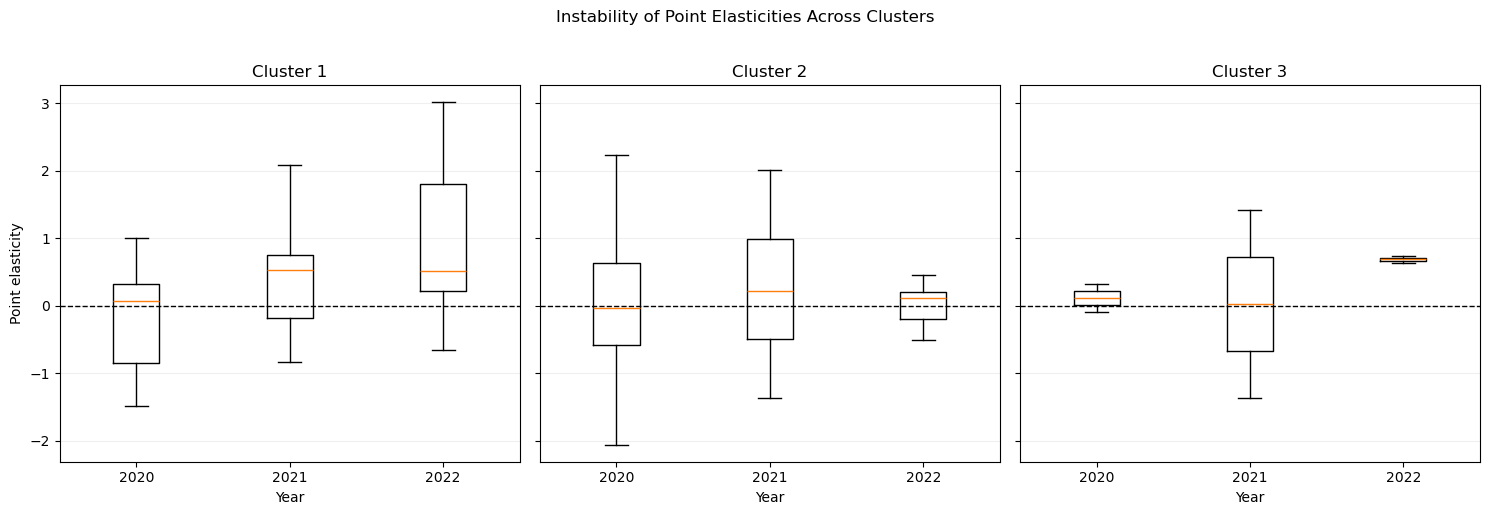

In [7]:
# =========================================================
# 5.1 Point Elasticities by Cluster (CLEAN VERSION)
# =========================================================

# --- 1. Build county features (NO sector shares) ---
features = [
    "ln_osr", "ln_gcp",
    "eff_rate",
    "osr_pc", "gcp_pc",
    "pop_density", "gcp_density",
    "dln_osr", "dln_gcp"
]

county_feats = (
    df.groupby("county", as_index=False)[features]
      .mean()
)

# --- 2. Clustering (k = 3) ---
X = county_feats[features].fillna(county_feats[features].median())
X_scaled = MinMaxScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
county_feats["cluster"] = kmeans.fit_predict(X_scaled) + 1   # 1,2,3

# --- 3. Merge clusters back ---
df = df.drop(columns="cluster", errors="ignore").merge(
    county_feats[["county", "cluster"]],
    on="county",
    how="left"
)

# --- 4. Elasticities (robust build) ---
eps = 1e-9

if "ln_osr" not in df.columns:
    df["ln_osr"] = np.log(df["osr"] + eps)

if "ln_gcp" not in df.columns:
    base = "gcp_nominal" if "gcp_nominal" in df.columns else "gcp"
    df["ln_gcp"] = np.log(df[base] + eps)

df = df.sort_values(["county", "year"]).reset_index(drop=True)

df["dln_osr"] = df.groupby("county")["ln_osr"].diff()
df["dln_gcp"] = df.groupby("county")["ln_gcp"].diff()

df["elas_point"] = df["dln_osr"] / (df["dln_gcp"] + eps)
df["elas_point"] = df["elas_point"].replace([np.inf, -np.inf], np.nan)

# --- 5. Prepare plotting ---
plot_df = df[["year", "cluster", "elas_point"]].dropna().copy()
plot_df["elas_point"] = plot_df["elas_point"].clip(-5, 5)

years = sorted(plot_df["year"].unique())
clusters = sorted(plot_df["cluster"].unique())

# --- 6. Plot ---
fig, axes = plt.subplots(1, len(clusters), figsize=(5*len(clusters),5), sharey=True)

if len(clusters) == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):
    sub = plot_df[plot_df["cluster"] == c]

    data, labels = [], []
    for y in years:
        vals = sub.loc[sub["year"] == y, "elas_point"].values
        if len(vals) > 0:
            data.append(vals)
            labels.append(y)

    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("Year")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Point elasticity")

plt.suptitle("Instability of Point Elasticities Across Clusters", y=1.02)
plt.tight_layout()
plt.savefig("point_elasticities_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.3 Visualising Cluster Differences

Once counties are assigned to structural clusters, the next step is to visualise what distinguishes these groups in economically meaningful terms. The purpose is not to generate additional clustering diagnostics, but to interpret the clusters in a way that is relevant for forecasting and policy.

The visualisations below focus on four dimensions:

- **Revenue capacity**, captured by OSR per capita relative to GCP per capita  
- **Fiscal effort**, captured by the effective OSR-to-GCP rate  
- **Economic structure**, captured by the average shares of agriculture, industry, and services  
- **Cluster composition**, captured by the number of counties in each group  

Together, these figures help show whether clusters differ mainly by scale, effort, structure, or a combination of all three. This provides a practical basis for differentiated modelling, since counties with distinct structural profiles are unlikely to follow the same revenue-generating process.

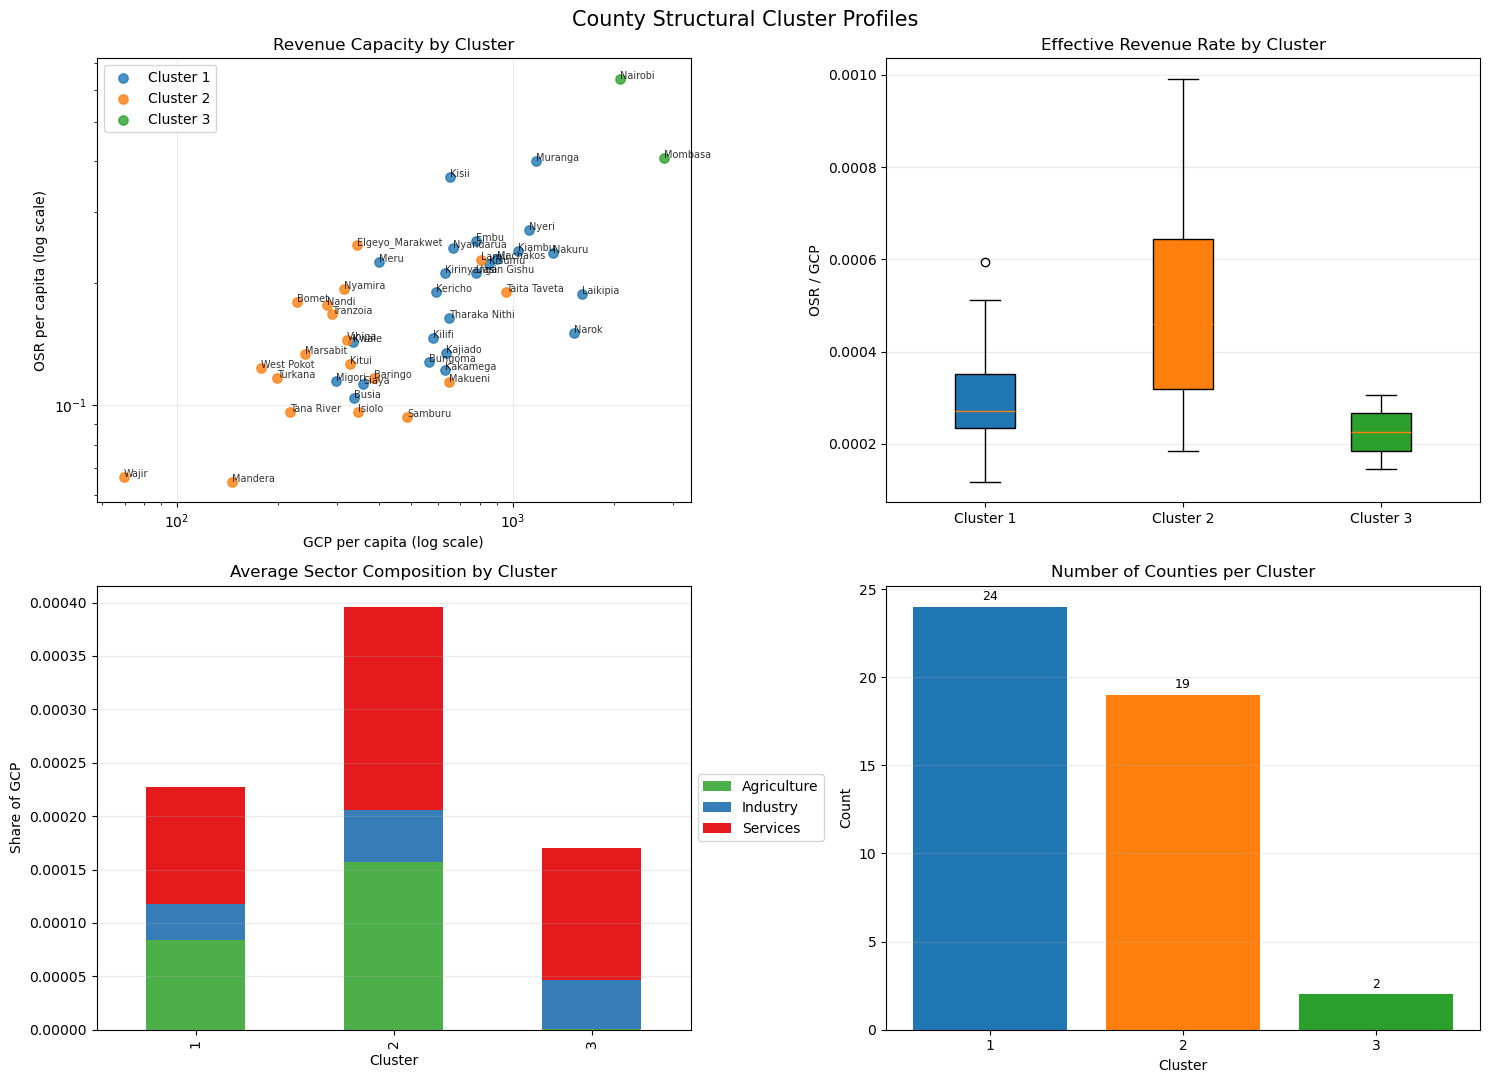


Counties by cluster
             county  cluster
2           Bungoma        1
3             Busia        1
5              Embu        1
7           Kajiado        1
8          Kakamega        1
9           Kericho        1
10           Kiambu        1
11           Kilifi        1
12       Kirinyanga        1
13            Kisii        1
14           Kisumu        1
16            Kwale        1
17         Laikipia        1
19         Machakos        1
23             Meru        1
24           Migori        1
26          Muranga        1
28           Nakuru        1
30            Narok        1
32        Nyandarua        1
33            Nyeri        1
35            Siaya        1
38    Tharaka Nithi        1
41      Uasin Gishu        1
0           Baringo        2
1             Bomet        2
4   Elgeyo_Marakwet        2
6            Isiolo        2
15            Kitui        2
18             Lamu        2
20          Makueni        2
21          Mandera        2
22         Marsabit   

,ln_osr,ln_gcp,osr_pc,gcp_pc,eff_rate,pop_density,gcp_density,dln_osr,dln_gcp,share_agri,share_industry,share_services
cluster,,,,,,,,,,,,
1,12.161,20.357,0.201,767.694,0.000,351.376,2.391606e+05,0.101,0.087,0.0,0.0,0.0
2,11.264,18.980,0.141,357.309,0.001,183.197,5.841047e+04,0.078,0.050,0.0,0.0,0.0
3,14.008,22.475,0.524,2456.506,0.000,6056.905,1.475031e+07,0.074,0.070,0.0,0.0,0.0


In [8]:
# =========================================================
# 4.3 Cluster Visualisation Dashboard
# One-cell version: prepare + visualize
# =========================================================


# optional: suppress non-analytical warnings
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. Ensure cluster is available in df
# ---------------------------------------------------------
if "cluster" not in df.columns:
    if "cluster" not in county_feats.columns:
        raise ValueError("Cluster labels not found. Run the clustering step first.")
    df = df.drop(columns=["cluster"], errors="ignore").merge(
        county_feats[["county", "cluster"]], on="county", how="left"
    )

# ---------------------------------------------------------
# 2. Build sector shares if missing
# ---------------------------------------------------------
required_share_cols = ["share_agri", "share_industry", "share_services"]

if not all(col in df.columns for col in required_share_cols):
    agri_cols = ["Agriculture, forestry and fishing"]

    industry_cols = [
        "Mining and quarrying",
        "Manufacturing",
        "Electricity supply",
        "Water Supply; Waste Collection",
        "Construction"
    ]

    service_cols = [
        "Wholesale & Retail Trade; Repair of Motor Vehicle",
        "Transport & Storage",
        "Accommodation & Food Service Activities",
        "Information & Communication",
        "Financial & Insurance Activities",
        "Real Estate Activities",
        "Professional & Technical Services",
        "Adminsitrative Support Services",
        "Public Administration & Defence",
        "Education",
        "Human Health & Social Workers",
        "Other Service Activities",
        "Financial Service Indirectly Measured"
    ]

    agri_cols = [c for c in agri_cols if c in df.columns]
    industry_cols = [c for c in industry_cols if c in df.columns]
    service_cols = [c for c in service_cols if c in df.columns]

    for cols in [agri_cols, industry_cols, service_cols]:
        for c in cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["gcp_agri"] = df[agri_cols].sum(axis=1) if agri_cols else 0.0
    df["gcp_industry"] = df[industry_cols].sum(axis=1) if industry_cols else 0.0
    df["gcp_services"] = df[service_cols].sum(axis=1) if service_cols else 0.0

    df["share_agri"] = df["gcp_agri"] / df["gcp_nominal"]
    df["share_industry"] = df["gcp_industry"] / df["gcp_nominal"]
    df["share_services"] = df["gcp_services"] / df["gcp_nominal"]

# ---------------------------------------------------------
# 3. Build county-level summary for visualisation
# ---------------------------------------------------------
features = [
    "ln_osr", "ln_gcp",
    "osr_pc", "gcp_pc",
    "eff_rate",
    "pop_density", "gcp_density",
    "dln_osr", "dln_gcp",
    "share_agri", "share_industry", "share_services"
]

features = [c for c in features if c in df.columns]

county_summary = (
    df.groupby(["county", "cluster"], as_index=False)[features]
      .mean()
)

# Cluster labels as 1, 2, 3
county_summary["cluster"] = county_summary["cluster"].astype(int)
if county_summary["cluster"].min() == 0:
    county_summary["cluster"] = county_summary["cluster"] + 1
    df["cluster"] = df["cluster"].astype(int) + 1

# ---------------------------------------------------------
# 4. Cluster composition table
# ---------------------------------------------------------
cluster_counts = (
    county_summary.groupby("cluster")["county"]
    .nunique()
    .reset_index(name="n_counties")
)

sector_means = (
    county_summary.groupby("cluster")[["share_agri", "share_industry", "share_services"]]
    .mean()
)

# ---------------------------------------------------------
# 5. 2x2 dashboard
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

cluster_colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

# Panel 1: Revenue capacity
for c in sorted(county_summary["cluster"].unique()):
    sub = county_summary[county_summary["cluster"] == c]
    axes[0].scatter(sub["gcp_pc"], sub["osr_pc"], s=45, alpha=0.8, label=f"Cluster {c}", color=cluster_colors.get(c))
    for _, r in sub.iterrows():
        axes[0].annotate(r["county"], (r["gcp_pc"], r["osr_pc"]), fontsize=7, alpha=0.8)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("GCP per capita (log scale)")
axes[0].set_ylabel("OSR per capita (log scale)")
axes[0].set_title("Revenue Capacity by Cluster")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

# Panel 2: Fiscal effort
box_data = [county_summary.loc[county_summary["cluster"] == c, "eff_rate"].dropna().values
            for c in sorted(county_summary["cluster"].unique())]

bp = axes[1].boxplot(
    box_data,
    labels=[f"Cluster {c}" for c in sorted(county_summary["cluster"].unique())],
    patch_artist=True
)
for patch, c in zip(bp["boxes"], sorted(county_summary["cluster"].unique())):
    patch.set_facecolor(cluster_colors.get(c))

axes[1].set_title("Effective Revenue Rate by Cluster")
axes[1].set_ylabel("OSR / GCP")
axes[1].grid(True, axis="y", alpha=0.25)

# Panel 3: Sector composition
sector_means.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    color=["#4daf4a", "#377eb8", "#e41a1c"]
)
axes[2].set_title("Average Sector Composition by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Share of GCP")
axes[2].legend(["Agriculture", "Industry", "Services"], loc="center left", bbox_to_anchor=(1, 0.5))
axes[2].grid(True, axis="y", alpha=0.25)

# Panel 4: Cluster composition
bars = axes[3].bar(
    cluster_counts["cluster"].astype(str),
    cluster_counts["n_counties"],
    color=[cluster_colors.get(c) for c in cluster_counts["cluster"]]
)
axes[3].set_title("Number of Counties per Cluster")
axes[3].set_xlabel("Cluster")
axes[3].set_ylabel("Count")
axes[3].grid(True, axis="y", alpha=0.25)

for bar in bars:
    h = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2, h + 0.2, f"{int(h)}",
                 ha="center", va="bottom", fontsize=9)

plt.suptitle("County Structural Cluster Profiles", fontsize=15, y=0.98)

plt.tight_layout()
plt.savefig("County Structural Cluster Profiles.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 6. Compact outputs for interpretation
# ---------------------------------------------------------
print("\nCounties by cluster")
print(county_summary[["county", "cluster"]].sort_values(["cluster", "county"]))

print("\nCluster summary")
display(
    county_summary.groupby("cluster")[features].mean().round(3)
)

## 4.3 Visualising Structural Differences Across County Clusters

Having classified counties into three structural groups, the next step is to show what distinguishes them in economically meaningful terms. The objective is not to repeat the clustering diagnostics, but to interpret the resulting groups in a way that informs forecasting and policy.

The figures below focus on four dimensions that matter directly for county own-source revenue modelling:

- **Revenue capacity**, measured by OSR per capita relative to GCP per capita  
- **Fiscal effort**, measured by the effective OSR-to-GCP rate  
- **Economic structure**, measured by the average shares of agriculture, industry, and services  
- **Cluster composition**, measured by the number of counties in each group  

These comparisons help clarify whether counties differ primarily by scale, revenue effort, or economic structure. This is important because structurally different counties should not be expected to follow the same revenue-generating process, and therefore should not automatically be assigned the same forecasting model.

In [9]:

viz_vars = [
    "ln_osr", "ln_gcp",
    "osr_pc", "gcp_pc",
    "eff_rate",
    "pop_density", "gcp_density",
    "dln_osr", "dln_gcp"
]

if "cluster" not in county_feats.columns:
    cluster_vars = [
        "ln_osr", "ln_gcp", "eff_rate",
        "osr_pc", "gcp_pc",
        "pop_density", "gcp_density",
        "dln_osr", "dln_gcp"
    ]
    X = county_feats[cluster_vars].fillna(county_feats[cluster_vars].median())
    X_scaled = MinMaxScaler().fit_transform(X)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
    county_feats["cluster"] = kmeans.fit_predict(X_scaled)

county_feats["cluster"] = county_feats["cluster"].astype(int)
if county_feats["cluster"].min() == 0:
    county_feats["cluster"] = county_feats["cluster"] + 1

df = df.drop(columns="cluster", errors="ignore").merge(
    county_feats[["county", "cluster"]],
    on="county",
    how="left"
)

df["cluster"] = df["cluster"].astype(int)
if df["cluster"].min() == 0:
    df["cluster"] = df["cluster"] + 1

county_summary = (
    df.groupby(["county", "cluster"], as_index=False)[viz_vars]
      .mean()
)

for col in viz_vars:
    county_summary[col] = pd.to_numeric(county_summary[col], errors="coerce")

cluster_counts = (
    county_summary.groupby("cluster")["county"]
    .nunique()
    .reset_index(name="n_counties")
)

cluster_ids = sorted(county_summary["cluster"].unique())

cluster_colors = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c"
}

fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ]
)

for c in cluster_ids:
    sub = county_summary[county_summary["cluster"] == c]
    fig.add_trace(
        go.Scatter(
            x=sub["gcp_pc"],
            y=sub["osr_pc"],
            mode="markers",
            marker=dict(size=9, color=cluster_colors[c]),
            name=f"Cluster {c}"
        ),
        row=1, col=1
    )

for c in cluster_ids:
    sub = county_summary[county_summary["cluster"] == c]
    fig.add_trace(
        go.Box(
            y=sub["eff_rate"],
            marker_color=cluster_colors[c],
            showlegend=False
        ),
        row=1, col=2
    )

fig.add_trace(
    go.Bar(
        x=cluster_counts["cluster"].astype(str),
        y=cluster_counts["n_counties"],
        marker_color=[cluster_colors[int(c)] for c in cluster_counts["cluster"]],
        showlegend=False
    ),
    row=2, col=1
)

for c in cluster_ids:
    sub = county_summary[county_summary["cluster"] == c]
    fig.add_trace(
        go.Scatter(
            x=sub["ln_gcp"],
            y=sub["ln_osr"],
            mode="markers",
            marker=dict(size=9, color=cluster_colors[c]),
            showlegend=False
        ),
        row=2, col=2
    )

fig.update_layout(
    height=800,
    width=1100,
    template="plotly_white"
)

fig.update_xaxes(type="log", row=1, col=1)
fig.update_yaxes(type="log", row=1, col=1)

fig.show()

fig.write_html("county_cluster_profiles.html")

try:
    fig.write_image("county_cluster_profiles.png", scale=2)
except:
    pass

## 5. Why Point Elasticities Are Not a Reliable Forecasting Tool

A common approach in county revenue forecasting is to **compute point elasticities** as the ratio of year-to-year growth in OSR to year-to-year growth in GCP. In principle, this is meant to show how strongly revenue responds to the economic base.

In practice, however, point elasticities are highly unstable in county data. They are sensitive to small changes in GCP growth, administrative shocks, timing effects, and one-off revenue movements. This often produces extreme values, sign reversals, and erratic swings that do not reflect a stable fiscal relationship.

For that reason, point elasticities are treated here as a diagnostic rather than a forecasting parameter. The purpose of the analysis below is to show why a mechanical elasticity-based approach is unreliable and why the modelling framework must move toward more stable, data-driven county-specific specifications.

Rows: 270 | Counties: 45
Non-missing point elasticities: 225
Max non-missing per county: 5
Counties plotted: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo_Marakwet', 'Embu', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi']


,n_non_missing,mean_elasticity,std_elasticity,min_elasticity,max_elasticity
county,,,,,
Bungoma,5,32.036,71.193,-0.814,159.385
Kilifi,5,15.730,28.018,0.213,64.957
Kisii,5,10.208,20.372,-0.407,46.469
Elgeyo_Marakwet,5,3.822,15.211,-11.656,29.345
Kirinyanga,5,-4.572,9.793,-22.066,0.518
Nandi,5,5.227,8.992,-0.503,21.054
Wajir,5,3.626,8.906,-0.773,19.531
Kwale,5,-3.045,7.679,-16.758,0.762
Turkana,5,4.580,7.240,-1.019,16.654


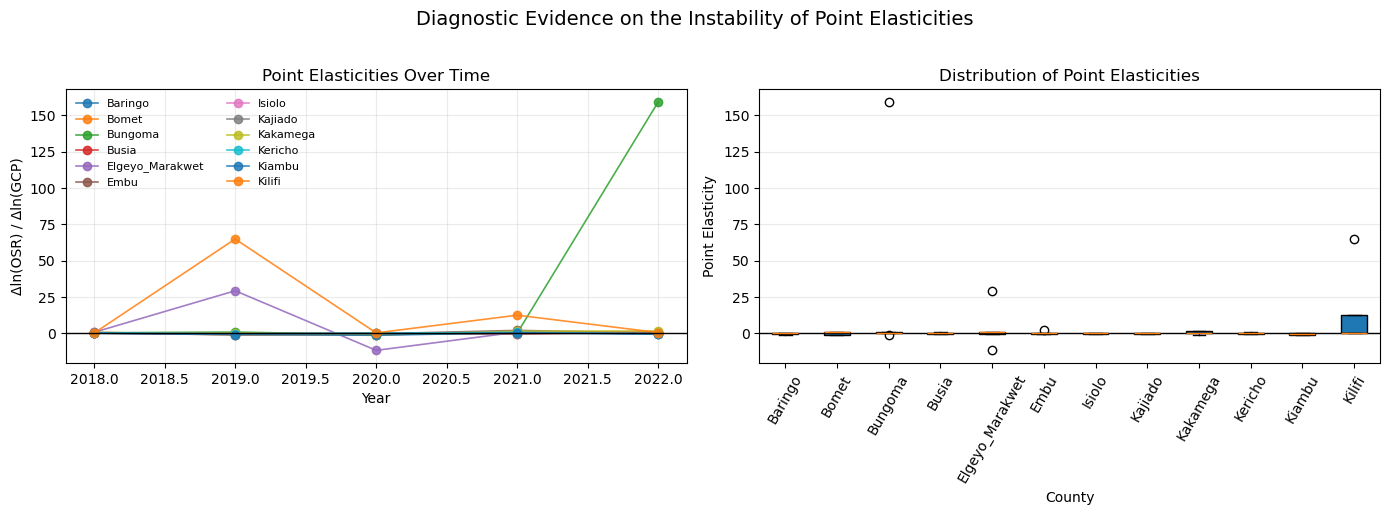

In [10]:
# =========================================================
# 5. Point Elasticity Diagnostics
# =========================================================

FILE = "OSR_Per_County 08_12_2025.xlsx"

# 5.1 Load and prepare data
df_pe = pd.read_excel(FILE)

df_pe.columns = (
    df_pe.columns.astype(str)
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

df_pe = df_pe.rename(columns={
    "County": "county",
    "Year": "year",
    "County_revenue": "osr",
    "Nominal_GCP": "gcp"
})

df_pe["county"] = df_pe["county"].astype(str).str.strip()
df_pe["year"] = pd.to_numeric(df_pe["year"], errors="coerce")

for c in ["osr", "gcp"]:
    df_pe[c] = pd.to_numeric(df_pe[c], errors="coerce")

df_pe = (
    df_pe.dropna(subset=["county", "year", "osr", "gcp"])
         .sort_values(["county", "year"])
         .reset_index(drop=True)
)
df_pe["year"] = df_pe["year"].astype(int)

# 5.2 Compute point elasticities
eps = 1e-9
df_pe["ln_osr"] = np.log(df_pe["osr"] + eps)
df_pe["ln_gcp"] = np.log(df_pe["gcp"] + eps)

df_pe["dln_osr"] = df_pe.groupby("county")["ln_osr"].diff()
df_pe["dln_gcp"] = df_pe.groupby("county")["ln_gcp"].diff()

df_pe["elas_point"] = df_pe["dln_osr"] / (df_pe["dln_gcp"] + eps)
df_pe["elas_point"] = df_pe["elas_point"].replace([np.inf, -np.inf], np.nan)

# 5.3 Keep counties with enough observations for illustration
valid_counts = df_pe.groupby("county")["elas_point"].apply(lambda s: s.notna().sum())
thr = 4
sample = (
    valid_counts[valid_counts >= thr]
    .sort_values(ascending=False)
    .head(12)
    .index.tolist()
)

# 5.4 Summary diagnostics
point_summary = pd.DataFrame({
    "n_non_missing": valid_counts,
    "mean_elasticity": df_pe.groupby("county")["elas_point"].mean(),
    "std_elasticity": df_pe.groupby("county")["elas_point"].std(),
    "min_elasticity": df_pe.groupby("county")["elas_point"].min(),
    "max_elasticity": df_pe.groupby("county")["elas_point"].max()
}).sort_values("std_elasticity", ascending=False)

print("Rows:", df_pe.shape[0], "| Counties:", df_pe["county"].nunique())
print("Non-missing point elasticities:", int(df_pe["elas_point"].notna().sum()))
print("Max non-missing per county:", int(valid_counts.max()))
print("Counties plotted:", sample)

display(point_summary.head(10).round(3))

# 5.5 Visualise instability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: time paths for sample counties
for c in sample:
    g = df_pe.loc[df_pe["county"] == c, ["year", "elas_point"]].dropna()
    if g.shape[0] >= 2:
        axes[0].plot(g["year"], g["elas_point"], marker="o", linewidth=1.2, alpha=0.85, label=c)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Point Elasticities Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Δln(OSR) / Δln(GCP)")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2, fontsize=8, frameon=False)

# Panel B: distribution across counties
elas_box = [
    df_pe.loc[df_pe["county"] == c, "elas_point"].dropna().values
    for c in sample if df_pe.loc[df_pe["county"] == c, "elas_point"].dropna().shape[0] >= 2
]
elas_labels = [
    c for c in sample if df_pe.loc[df_pe["county"] == c, "elas_point"].dropna().shape[0] >= 2
]

axes[1].boxplot(elas_box, labels=elas_labels, patch_artist=True)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Distribution of Point Elasticities")
axes[1].set_xlabel("County")
axes[1].set_ylabel("Point Elasticity")
axes[1].tick_params(axis="x", rotation=60)
axes[1].grid(True, axis="y", alpha=0.25)

plt.suptitle("Diagnostic Evidence on the Instability of Point Elasticities", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("point_elasticity_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

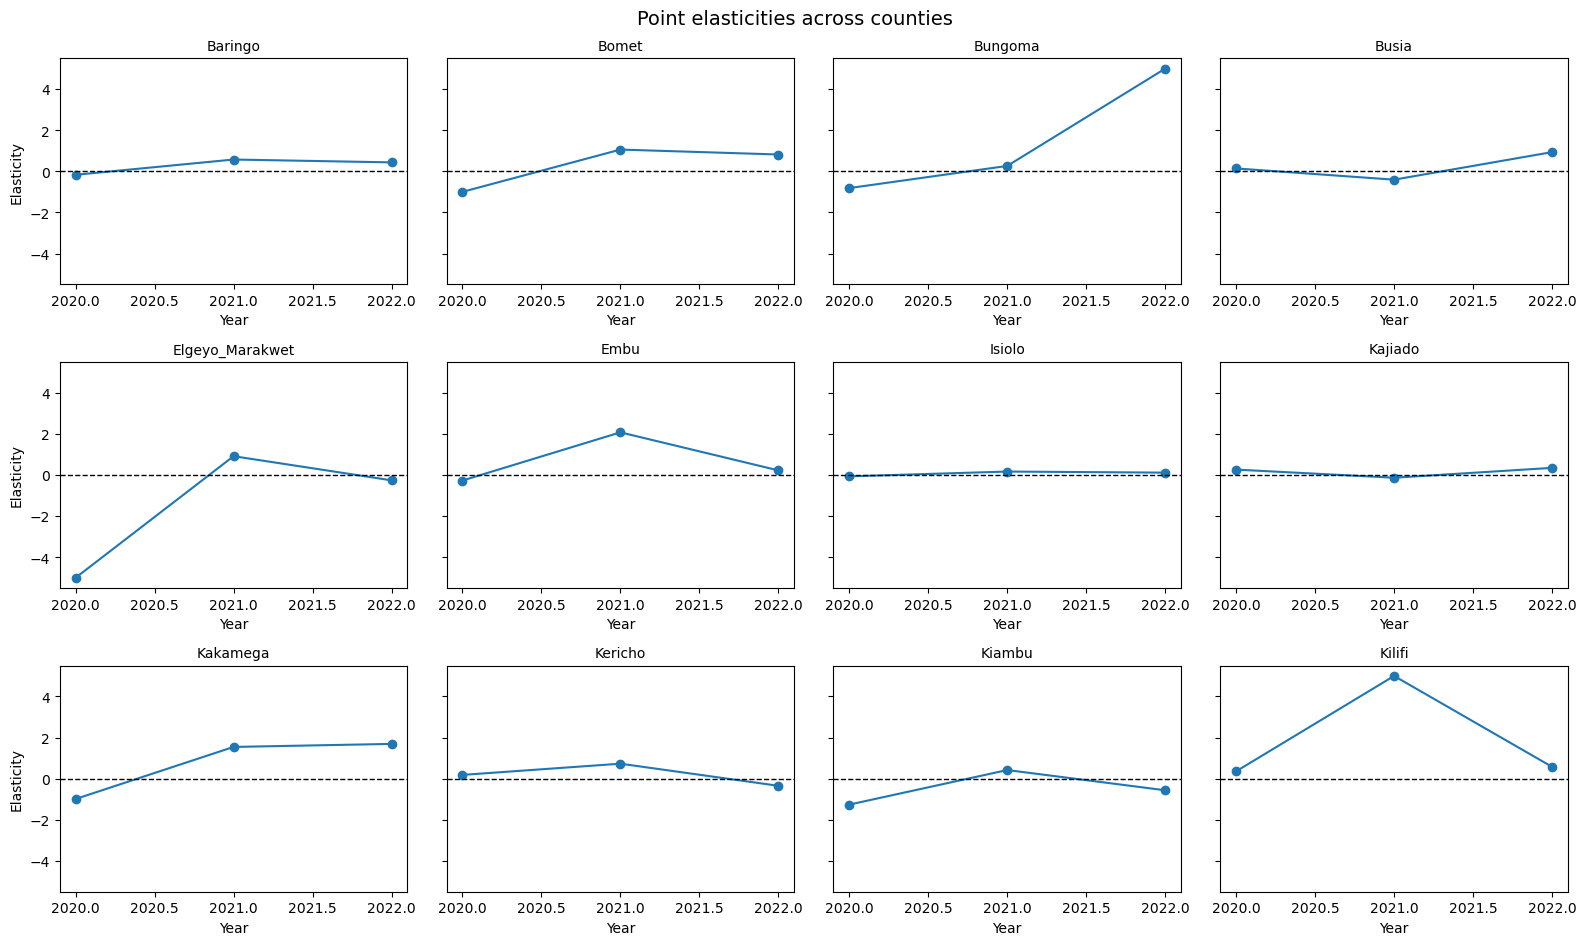

In [11]:
import math

valid_counts = df.groupby("county")["elas_point"].apply(lambda s: s.notna().sum())

thr = 4
counties = valid_counts[valid_counts >= thr].sort_values(ascending=False).index.tolist()

# fallback if threshold is too strict
if len(counties) == 0:
    thr = 2
    counties = valid_counts[valid_counts >= thr].sort_values(ascending=False).index.tolist()

# keep only top 12
counties = counties[:12]

# stop early if still empty
if len(counties) == 0:
    print("No counties have enough non-missing point elasticities to plot.")
else:
    cols = 4
    rows = math.ceil(len(counties) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.2 * rows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for i, c in enumerate(counties):
        g = df.loc[df["county"] == c, ["year", "elas_point"]].dropna().copy()
        g["elas_point"] = g["elas_point"].clip(-5, 5)

        axes[i].plot(g["year"], g["elas_point"], marker="o", linewidth=1.5)
        axes[i].axhline(0, linestyle="--", linewidth=1, color="black")
        axes[i].set_title(c, fontsize=10)
        axes[i].set_xlabel("Year")

        if i % cols == 0:
            axes[i].set_ylabel("Elasticity")

    for j in range(len(counties), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Point elasticities across counties", fontsize=14)
    plt.tight_layout()
    plt.show()

## 5.1 Point Elasticities by Cluster

To test whether point elasticities become more informative once counties are grouped into structurally similar clusters, we examine their distribution within each cluster over time. If point elasticities were a stable basis for forecasting, they would be expected to show consistent sign and limited dispersion within clusters.

The results show the opposite. Even within structurally similar county groups, point elasticities remain highly dispersed and unstable across years. This indicates that the weakness of point elasticities is not simply due to cross-county heterogeneity. Rather, point elasticity itself is too noisy to serve as a reliable forecasting parameter in county-level revenue analysis.

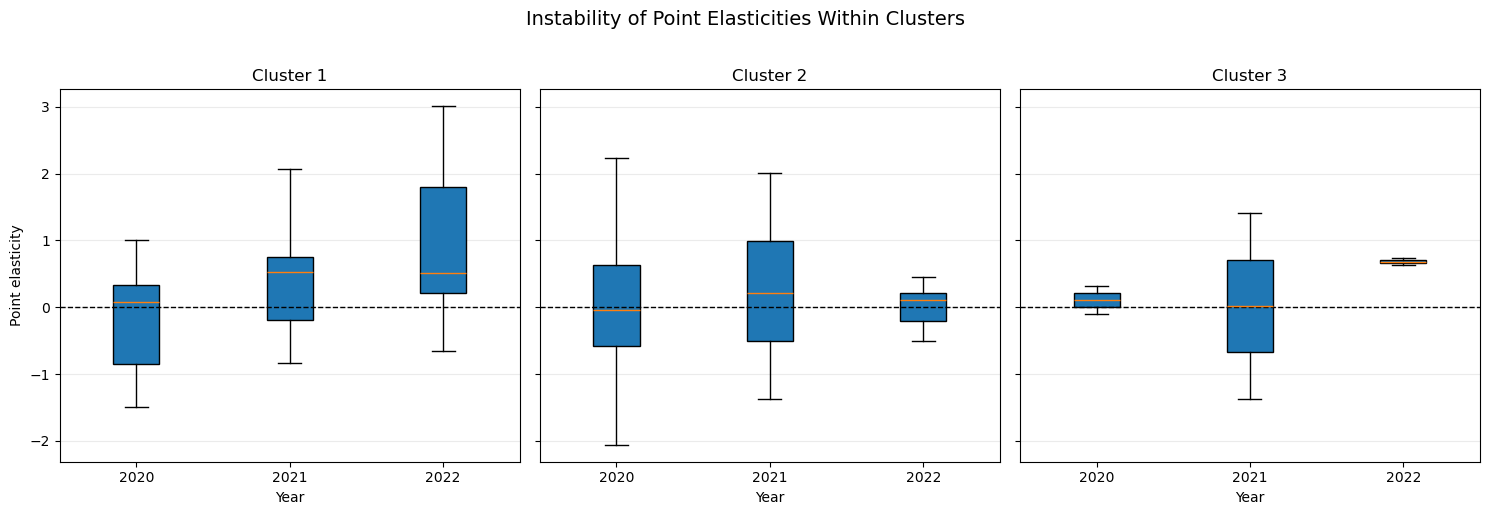

Unique clusters in df: [np.int64(1), np.int64(2), np.int64(3)]
Non-missing point elasticities: 135
Observations used in plot: 135


In [12]:
# =========================================================
# 5.1 Point Elasticities by Cluster – Full Working Code
# =========================================================

# 1. Ensure cluster labels exist in county_feats and start at 1
if "cluster" not in county_feats.columns:
    raise ValueError("Cluster labels not found in county_feats. Run the clustering step first.")

if county_feats["cluster"].min() == 0:
    county_feats["cluster"] = county_feats["cluster"] + 1

# 2. Merge clusters back into the main panel df
df = df.drop(columns="cluster", errors="ignore").merge(
    county_feats[["county", "cluster"]],
    on="county",
    how="left"
)

# 3. Ensure logs and point elasticities exist
eps = 1e-9

if "ln_osr" not in df.columns:
    df["ln_osr"] = np.log(df["osr"] + eps)

if "ln_gcp" not in df.columns:
    # Use gcp_nominal if available, otherwise gcp
    if "gcp_nominal" in df.columns:
        df["ln_gcp"] = np.log(df["gcp_nominal"] + eps)
    elif "gcp" in df.columns:
        df["ln_gcp"] = np.log(df["gcp"] + eps)
    else:
        raise ValueError("Neither 'gcp_nominal' nor 'gcp' found in df.")

# Sort before differences
df = df.sort_values(["county", "year"]).reset_index(drop=True)

if "dln_osr" not in df.columns:
    df["dln_osr"] = df.groupby("county")["ln_osr"].diff()

if "dln_gcp" not in df.columns:
    df["dln_gcp"] = df.groupby("county")["ln_gcp"].diff()

if "elas_point" not in df.columns:
    df["elas_point"] = df["dln_osr"] / (df["dln_gcp"] + eps)
    df["elas_point"] = df["elas_point"].replace([np.inf, -np.inf], np.nan)

# 4. Prepare plotting dataframe
plot_df = df[["year", "cluster", "elas_point"]].dropna().copy()

# Ensure clean cluster labels
plot_df["cluster"] = plot_df["cluster"].astype(int)

# Cap extreme values for readability only
plot_df["elas_point_plot"] = plot_df["elas_point"].clip(-5, 5)

years = sorted(plot_df["year"].unique())
clusters = sorted(plot_df["cluster"].unique())

# 5. Plot
fig, axes = plt.subplots(1, len(clusters), figsize=(5 * len(clusters), 5), sharey=True)

if len(clusters) == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):
    sub = plot_df[plot_df["cluster"] == c].copy()

    data = []
    valid_years = []

    for y in years:
        vals = sub.loc[sub["year"] == y, "elas_point_plot"].dropna().values
        if len(vals) > 0:
            data.append(vals)
            valid_years.append(y)

    if len(data) > 0:
        ax.boxplot(
            data,
            tick_labels=valid_years,
            showfliers=False,
            patch_artist=True
        )
        ax.axhline(0, linestyle="--", linewidth=1, color="black")
        ax.set_title(f"Cluster {c}")
        ax.set_xlabel("Year")
        ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Point elasticity")
plt.suptitle("Instability of Point Elasticities Within Clusters", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("point_elasticities_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Quick check
print("Unique clusters in df:", sorted(df["cluster"].dropna().unique()))
print("Non-missing point elasticities:", int(df["elas_point"].notna().sum()))
print("Observations used in plot:", plot_df.shape[0])

## Interpretation: Why Point Elasticities Break Down

The diagnostics clearly show that point elasticities are not stable or economically interpretable at the county level.

First, the time paths exhibit extreme volatility, with some counties showing sharp spikes and reversals from one year to the next. These movements are not consistent with underlying economic structure, but rather reflect noise from small denominators, administrative timing, and one-off revenue shocks.

Second, the distribution is heavily distorted by outliers. A few observations produce extremely large elasticity values, while most cluster near zero. This indicates that the measure is not capturing a systematic relationship between OSR and GCP, but is instead driven by irregular fluctuations.

From a policy perspective, this means:

- Point elasticities **cannot be used for forecasting**, as they are unstable and highly sensitive to short-term shocks.
- They **do not reflect structural revenue capacity**, which is what matters for fiscal planning.
- Reliance on this method would lead to **misleading projections and poor policy calibration**.

The evidence therefore justifies moving away from point elasticity-based approaches toward more stable, data-driven models that capture underlying county characteristics and revenue structures.

## 6. Effective Revenue Rates as a More Stable Forecasting Anchor

Given the instability of point elasticities, we turn to the effective revenue rate, defined as own-source revenue relative to Gross County Product. Unlike year-to-year elasticities, this measure captures the share of the economic base that is effectively translated into revenue and is therefore easier to interpret in fiscal terms.

The diagnostics below assess effective rates along four dimensions:
- their average evolution over time within clusters,
- their dispersion across counties within each cluster,
- their relative stability compared with point elasticities,
- and their behaviour for a sample of counties over time.

If effective rates are more stable than point elasticities, they provide a stronger basis for forecasting because they reflect structural fiscal effort rather than short-term noise. This makes them a more credible intermediate anchor between the economic base and projected county revenue.

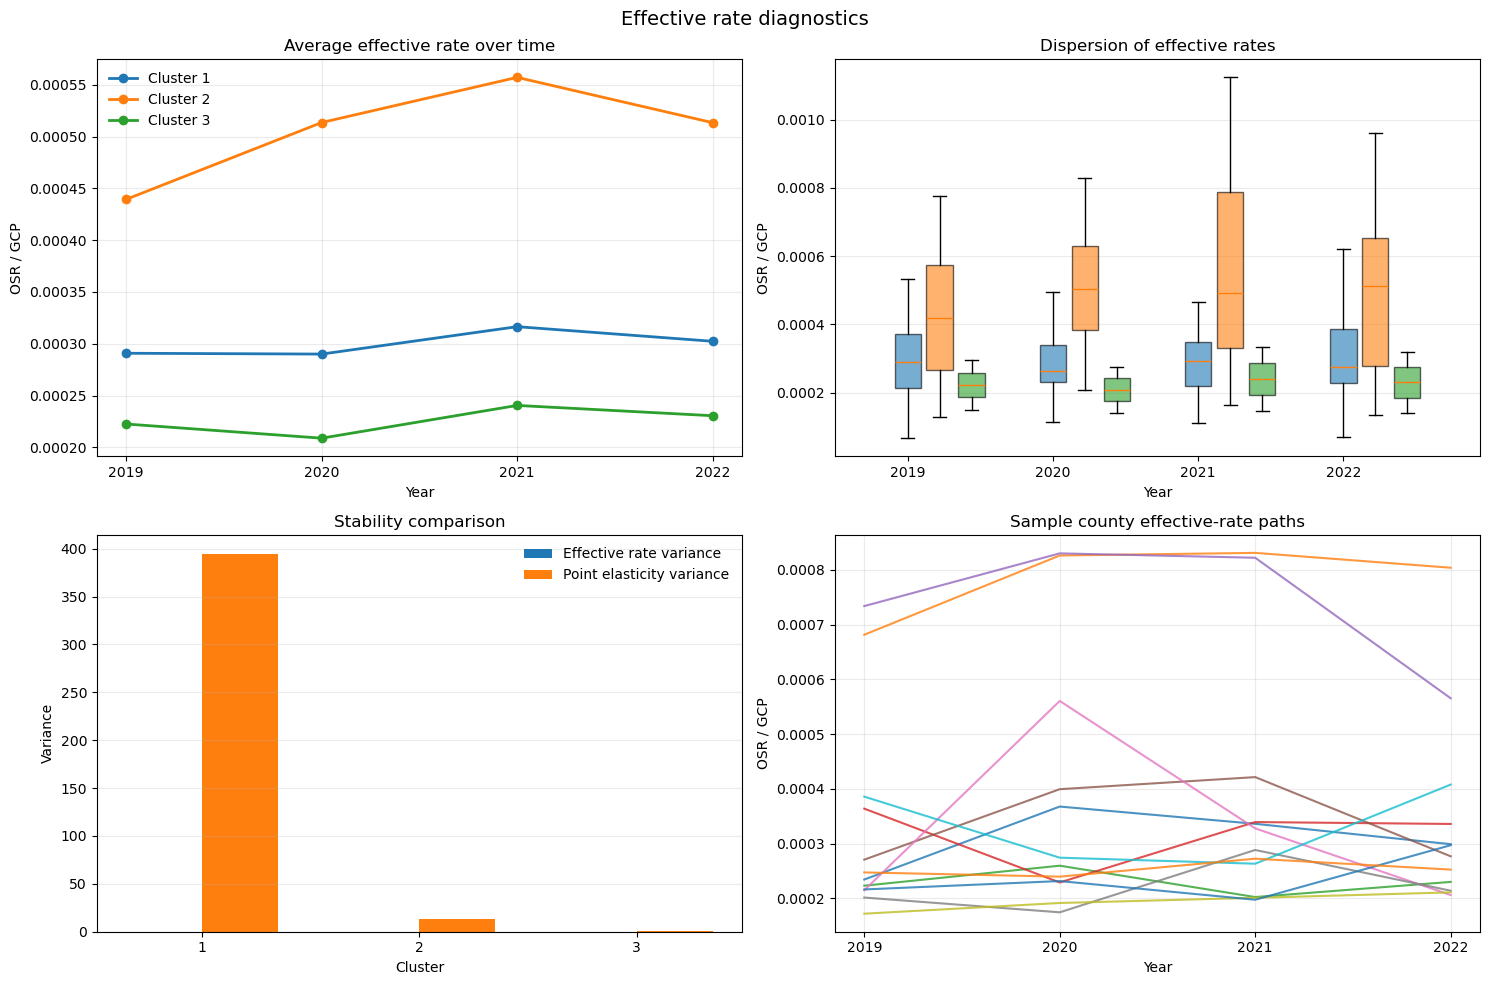

In [13]:
# 6. Effective rate diagnostics

# basic checks
needed = ["county", "year", "cluster", "osr"]
base_col = "gcp_nominal" if "gcp_nominal" in df.columns else "gcp"
needed.append(base_col)

missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# prepare
d = df.copy()
d["year"] = pd.to_numeric(d["year"], errors="coerce")
d["cluster"] = pd.to_numeric(d["cluster"], errors="coerce")
d["osr"] = pd.to_numeric(d["osr"], errors="coerce")
d[base_col] = pd.to_numeric(d[base_col], errors="coerce")

d = d.dropna(subset=["county", "year", "cluster", "osr", base_col]).copy()
d["year"] = d["year"].astype(int)
d["cluster"] = d["cluster"].astype(int)

# cluster labels 1,2,3
if d["cluster"].min() == 0:
    d["cluster"] = d["cluster"] + 1

# effective rate
eps = 1e-9
d["eff_rate"] = d["osr"] / (d[base_col] + eps)

# point elasticity if missing
if "elas_point" not in d.columns:
    if "ln_osr" not in d.columns:
        d["ln_osr"] = np.log(d["osr"] + eps)
    if "ln_gcp" not in d.columns:
        d["ln_gcp"] = np.log(d[base_col] + eps)

    d = d.sort_values(["county", "year"]).reset_index(drop=True)
    d["dln_osr"] = d.groupby("county")["ln_osr"].diff()
    d["dln_gcp"] = d.groupby("county")["ln_gcp"].diff()
    d["elas_point"] = d["dln_osr"] / (d["dln_gcp"] + eps)
    d["elas_point"] = d["elas_point"].replace([np.inf, -np.inf], np.nan)

years = sorted(d["year"].unique())
clusters = sorted(d["cluster"].unique())

# summaries
cluster_ts = (
    d.groupby(["cluster", "year"])["eff_rate"]
     .agg(["mean", "median", "std"])
     .reset_index()
)

stability_compare = (
    d.groupby("cluster")
     .agg(
         var_eff_rate=("eff_rate", "var"),
         var_point_elas=("elas_point", "var")
     )
     .reset_index()
)

# sample counties: prefer broad coverage
county_counts = d.groupby("county")["year"].nunique().sort_values(ascending=False)
sample_counties = county_counts.head(min(12, len(county_counts))).index.tolist()

# colors
cluster_colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

# dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# panel 1: cluster mean effective rates over time
for c in clusters:
    g = cluster_ts[cluster_ts["cluster"] == c].sort_values("year")
    axes[0].plot(
        g["year"], g["mean"],
        marker="o", linewidth=2,
        label=f"Cluster {c}",
        color=cluster_colors.get(c)
    )

axes[0].set_title("Average effective rate over time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("OSR / GCP")
axes[0].set_xticks(years)
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)

# panel 2: dispersion by cluster and year
for i, c in enumerate(clusters):
    sub = d[d["cluster"] == c]
    data = [sub.loc[sub["year"] == y, "eff_rate"].dropna().values for y in years]
    valid = [(y, arr) for y, arr in zip(years, data) if len(arr) > 0]

    if len(valid) > 0:
        valid_years, valid_data = zip(*valid)
        pos = np.arange(len(valid_years)) + i * 0.22
        bp = axes[1].boxplot(
            valid_data,
            positions=pos,
            widths=0.18,
            patch_artist=True,
            showfliers=False
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(cluster_colors.get(c))
            patch.set_alpha(0.6)

axes[1].set_title("Dispersion of effective rates")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("OSR / GCP")
axes[1].set_xticks(np.arange(len(years)))
axes[1].set_xticklabels(years)
axes[1].grid(True, axis="y", alpha=0.25)

# panel 3: variance comparison
x = np.arange(len(clusters))
w = 0.35

axes[2].bar(
    x - w/2,
    stability_compare["var_eff_rate"],
    width=w,
    label="Effective rate variance"
)
axes[2].bar(
    x + w/2,
    stability_compare["var_point_elas"].fillna(0),
    width=w,
    label="Point elasticity variance"
)

axes[2].set_title("Stability comparison")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Variance")
axes[2].set_xticks(x)
axes[2].set_xticklabels(stability_compare["cluster"].astype(str))
axes[2].grid(True, axis="y", alpha=0.25)
axes[2].legend(frameon=False)

# panel 4: sample county paths
for county in sample_counties:
    g = d[d["county"] == county].sort_values("year")
    axes[3].plot(g["year"], g["eff_rate"], linewidth=1.5, alpha=0.8)

axes[3].set_title("Sample county effective-rate paths")
axes[3].set_xlabel("Year")
axes[3].set_ylabel("OSR / GCP")
axes[3].set_xticks(years)
axes[3].grid(True, alpha=0.25)

plt.suptitle("Effective rate diagnostics", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("effective_rate_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

## The effective rate diagnostics reveal a clear and economically meaningful structure across counties.
The effective rate diagnostics show clear and structured patterns across counties. Average effective rates differ systematically across clusters, with some groups consistently generating higher revenue relative to their economic base, while others remain persistently low. This separation is stable over time, suggesting underlying structural differences in fiscal capacity and revenue mobilisation. 

Dispersion within clusters remains moderate and contained, especially when compared to the extreme variability observed in point elasticities. While higher-capacity clusters exhibit some heterogeneity, the overall spread is economically plausible and does not reflect instability. At the county level, effective rates evolve smoothly over time, with gradual adjustments rather than sharp fluctuations, reinforcing their interpretability as a measure of fiscal effort.

However, this stability must be interpreted with caution. **A stable effective rate does not necessarily imply a meaningful or reliable relationship between revenue and the underlying economic base.** In cases where OSR and GCP are weakly linked or decoupled, the effective rate may remain stable while losing predictive content. In such settings, it reflects persistence in ratios rather than a true transmission from economic activity to revenue.

The implication is that effective rates are best viewed as a structural diagnostic tool rather than a universal forecasting anchor. Their use in modelling should be conditional on evidence of co-movement between revenue and the base. Where this relationship is weak, trend-based approaches provide a more credible foundation for forecasting, capturing the persistence and institutional dynamics that drive county revenue performance.

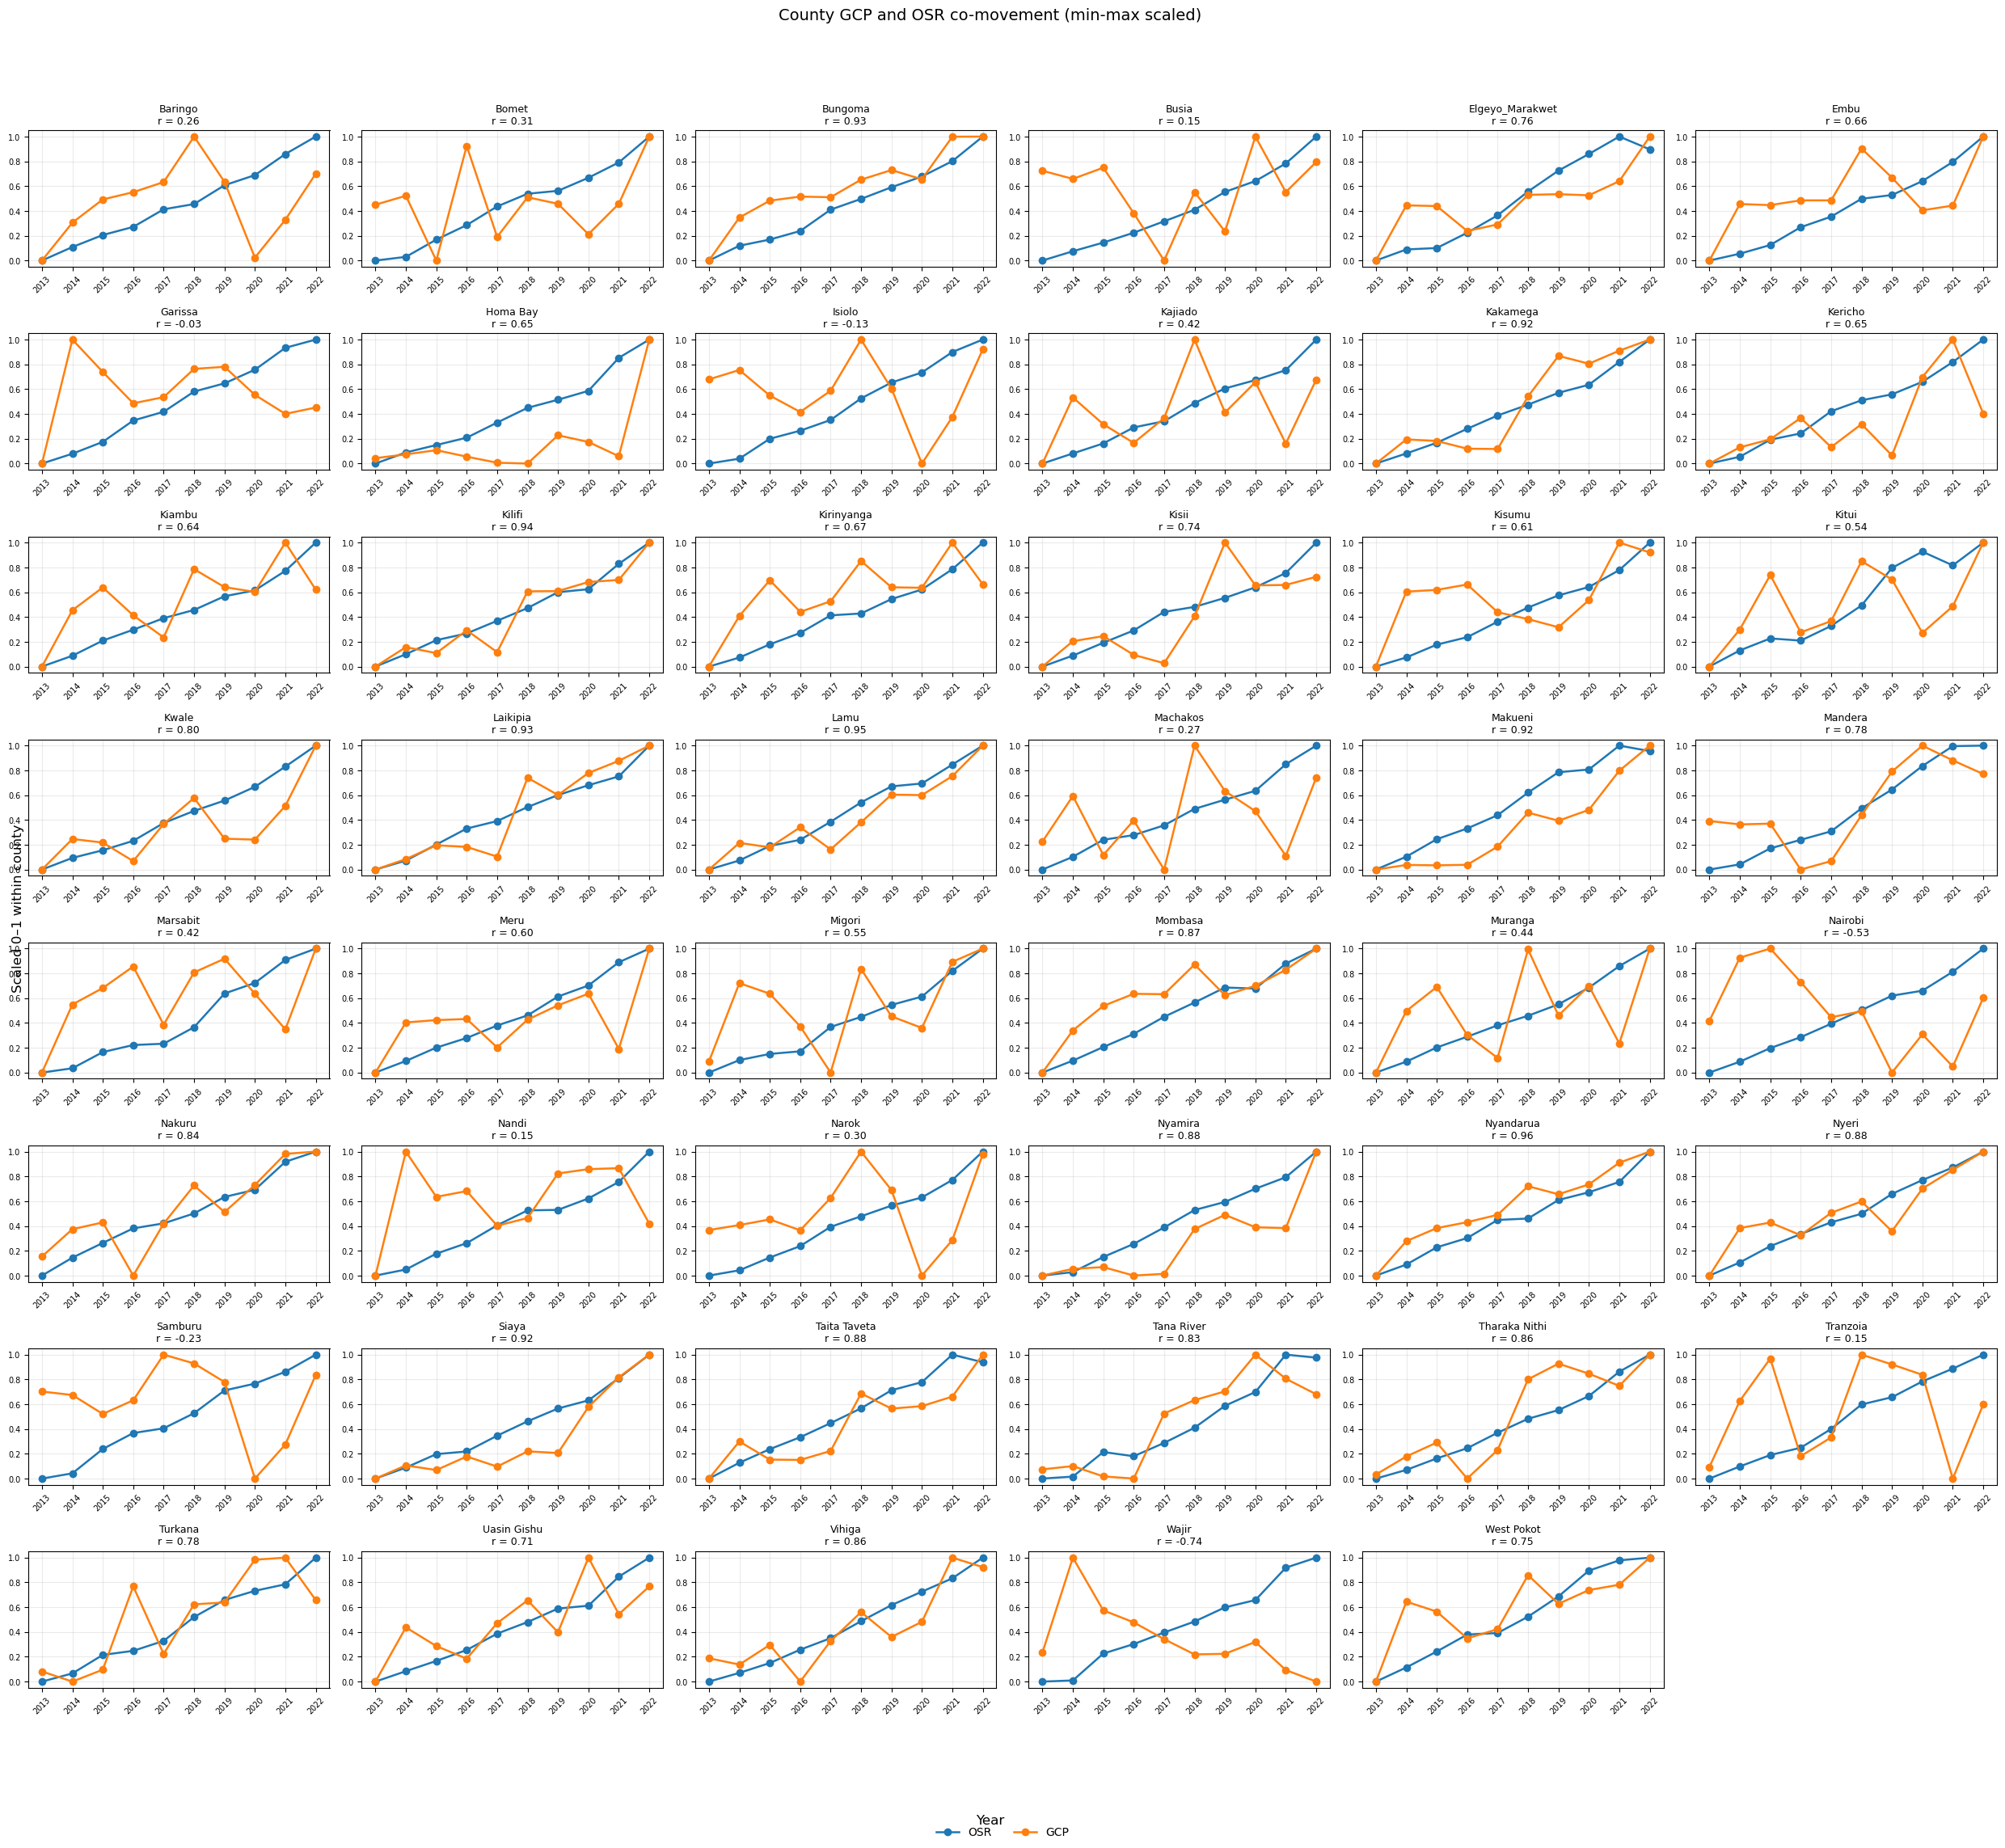

In [14]:

#We want to see if revenue and GCP co-move
path = "County OSR Data -2013 to 2023-10 years.xlsx"
df = pd.read_excel(path)

# clean column names
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace("\n", " ", regex=False)
      .str.replace(r"\s+", "_", regex=True)
)

# map key fields
rename_map = {}
for c in df.columns:
    if c == "county":
        rename_map[c] = "county"
    elif c == "year":
        rename_map[c] = "year"
    elif c in ["nominal_gcp", "gcp", "county_gcp", "gcp_nominal"]:
        rename_map[c] = "gcp"
    elif c in ["county_revenue", "osr", "county_osr", "revenue"]:
        rename_map[c] = "osr"

df = df.rename(columns=rename_map)

needed = ["county", "year", "gcp", "osr"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns after renaming: {missing}")

# clean types
df["county"] = df["county"].astype(str).str.strip()
df["year"] = pd.to_numeric(df["year"], errors="coerce")

for col in ["gcp", "osr"]:
    df[col] = (
        df[col].astype(str)
               .str.replace(",", "", regex=False)
               .str.replace(" ", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = (
    df.dropna(subset=["county", "year", "gcp", "osr"])
      .query("gcp > 0 and osr > 0")
      .sort_values(["county", "year"])
      .reset_index(drop=True)
)

df["year"] = df["year"].astype(int)

# choose scaling method: "minmax", "index", or "zscore"
method = "minmax"

def scale_index(x):
    base = x.iloc[0] if len(x) > 0 else np.nan
    if pd.isna(base) or base == 0:
        return pd.Series(np.nan, index=x.index)
    return x / base

def scale_minmax(x):
    mn, mx = x.min(), x.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.nan, index=x.index)
    return (x - mn) / (mx - mn)

def scale_zscore(x):
    mu, sd = x.mean(), x.std(ddof=0)
    if pd.isna(mu) or pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=x.index)
    return (x - mu) / sd

if method == "index":
    df["gcp_scaled"] = df.groupby("county")["gcp"].transform(scale_index)
    df["osr_scaled"] = df.groupby("county")["osr"].transform(scale_index)
    ylab = "Index (first year = 1)"
    main_title = "County GCP and OSR co-movement (indexed)"
elif method == "zscore":
    df["gcp_scaled"] = df.groupby("county")["gcp"].transform(scale_zscore)
    df["osr_scaled"] = df.groupby("county")["osr"].transform(scale_zscore)
    ylab = "Z-score within county"
    main_title = "County GCP and OSR co-movement (z-scores)"
else:
    df["gcp_scaled"] = df.groupby("county")["gcp"].transform(scale_minmax)
    df["osr_scaled"] = df.groupby("county")["osr"].transform(scale_minmax)
    ylab = "Scaled 0–1 within county"
    main_title = "County GCP and OSR co-movement (min-max scaled)"

# optional correlation for subtitle
corr_df = (
    df.groupby("county")[["gcp_scaled", "osr_scaled"]]
      .corr()
      .reset_index()
)
corr_df = corr_df[corr_df["level_1"] == "gcp_scaled"][["county", "osr_scaled"]]
corr_df = corr_df.rename(columns={"osr_scaled": "corr_scaled"})
df = df.merge(corr_df, on="county", how="left")

counties = sorted(df["county"].unique())
n = len(counties)
ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.9 * nrows))
axes = np.array(axes).reshape(-1)

for i, county in enumerate(counties):
    ax = axes[i]
    g = df[df["county"] == county].sort_values("year")

    ax.plot(g["year"], g["osr_scaled"], marker="o", linewidth=1.8, label="OSR")
    ax.plot(g["year"], g["gcp_scaled"], marker="o", linewidth=1.8, label="GCP")

    corr_txt = g["corr_scaled"].iloc[0]
    if pd.notna(corr_txt):
        ax.set_title(f"{county}\nr = {corr_txt:.2f}", fontsize=9)
    else:
        ax.set_title(county, fontsize=9)

    ax.set_xticks(g["year"])
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.25)

# turn off unused panels
for j in range(n, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=10)

fig.suptitle(main_title, fontsize=14)
fig.supxlabel("Year")
fig.supylabel(ylab)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("county_gcp_vs_osr_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()


## Decoupling of GCP and OSR Across Counties

The dashboard shows that, in many counties, OSR does not move closely with GCP. Although both series are scaled within county to make their trajectories comparable, the expected co-movement is frequently weak, intermittent, or unstable. In several cases, GCP follows a relatively smooth upward path while OSR displays sharp swings, delayed responses, or reversals that are not mirrored in the economic base. This pattern is evidence of **decoupling** between county revenue performance and underlying economic activity.

This matters directly for model choice. Where GCP and OSR move together in a sustained way, GCP can provide useful forecasting information. However, where decoupling is evident, the economic base cannot be treated as a reliable anchor for revenue prediction. In such counties, models that force OSR to track GCP risk adding noise rather than improving accuracy. The dashboard therefore supports a selective modelling strategy: GCP-based terms should only be used where co-movement is empirically credible, while trend-based specifications should remain the default foundation for county OSR forecasting in the presence of decoupling.

## OSR–GCP Linkage and Revenue Extraction

The  figure below contrasts two dimensions of county revenue performance: **economic linkage** (correlation between ln(OSR) and ln(GCP)) and **revenue extraction intensity** (average OSR/GCP).

Counties on the right (green bars) exhibit strong positive co-movement between revenue and the economic base, indicating that OSR evolves in line with underlying economic activity. In contrast, counties toward the left (orange to red bars) show weak or negative linkage, reflecting **decoupling**, where revenue does not track GCP.

The effective tax rate (red dots) introduces an important distinction. Several counties with weak or negative linkage still display moderate or high revenue extraction. This indicates that **revenue effort can remain strong even when it is not anchored to economic fundamentals**.

This evidence shows that revenue performance across counties is structurally heterogeneous. In some cases, OSR is closely tied to economic activity, while in others it is driven by administrative, institutional, or policy factors. *This distinction is critical for modelling, as it determines whether economic-base-driven approaches are appropriate or whether alternative anchors are required*.

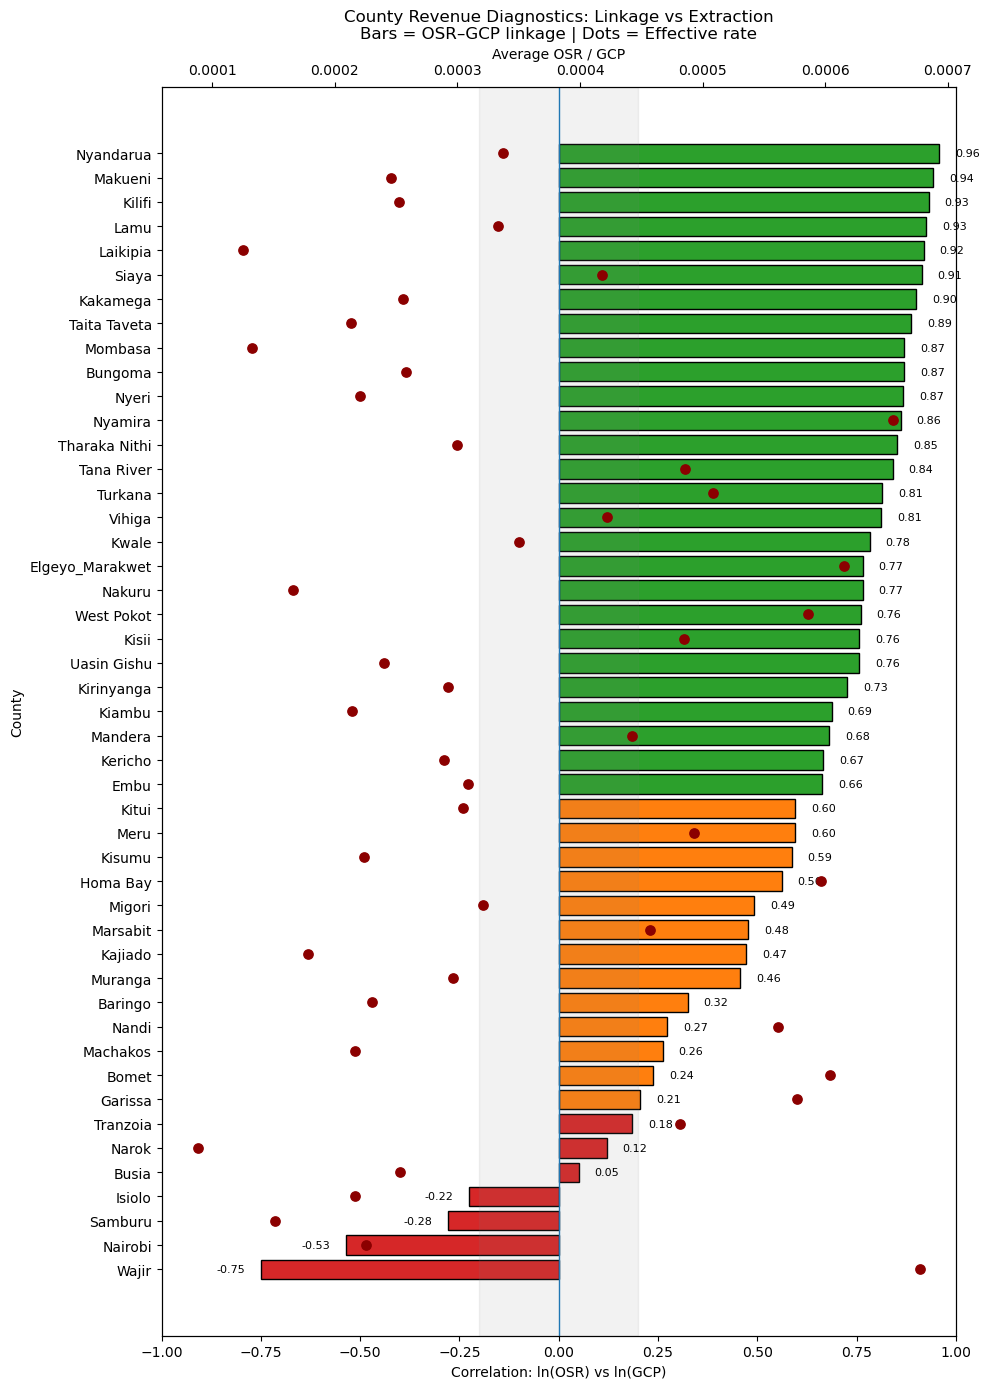

In [15]:
# --------------------------------------------------
# 1. Build overlay dataset
# --------------------------------------------------

df_plot = df.copy()

# logs
df_plot["ln_osr"] = np.log(df_plot["osr"])
df_plot["ln_gcp"] = np.log(df_plot["gcp"])

# --- Correlation per county (ln variables)
corr_df = (
    df_plot.groupby("county")[["ln_osr", "ln_gcp"]]
           .corr()
           .reset_index()
)

corr_df = corr_df[corr_df["level_1"] == "ln_osr"]
corr_df = corr_df.rename(columns={"ln_gcp": "corr_ln_osr_ln_gcp"})
corr_df = corr_df[["county", "corr_ln_osr_ln_gcp"]]

# --- Effective rate
df_plot["eff_rate"] = df_plot["osr"] / df_plot["gcp"]

etr_df = (
    df_plot.groupby("county")["eff_rate"]
           .mean()
           .reset_index()
           .rename(columns={"eff_rate": "etr_mean"})
)

# --- Merge
overlay_df = corr_df.merge(etr_df, on="county", how="inner")

# --------------------------------------------------
# 2. Define colors (based on linkage strength)
# --------------------------------------------------
def color_map(x):
    if x > 0.6:
        return "#2ca02c"   # strong linkage
    elif x > 0.2:
        return "#ff7f0e"   # moderate
    else:
        return "#d62728"   # weak / decoupled

bar_colors = overlay_df["corr_ln_osr_ln_gcp"].apply(color_map)

# --------------------------------------------------
# 3. Plot
# --------------------------------------------------

import matplotlib.pyplot as plt

# sort for clarity
plot_df = overlay_df.sort_values("corr_ln_osr_ln_gcp")

fig, ax1 = plt.subplots(figsize=(10, 14))

# --- Bars: correlation
bars = ax1.barh(
    plot_df["county"],
    plot_df["corr_ln_osr_ln_gcp"],
    color=bar_colors.loc[plot_df.index],
    edgecolor="black"
)

ax1.axvline(0, linewidth=1)
ax1.set_xlim(-1, 1)
ax1.set_xlabel("Correlation: ln(OSR) vs ln(GCP)")
ax1.set_ylabel("County")

# labels
for bar in bars:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height()/2

    ax1.text(
        w + (0.04 if w >= 0 else -0.04),
        y,
        f"{w:.2f}",
        va="center",
        ha="left" if w >= 0 else "right",
        fontsize=8
    )

# --- Effective rate (dots)
ax2 = ax1.twiny()
ax2.scatter(
    plot_df["etr_mean"],
    plot_df["county"],
    color="darkred",
    s=45
)

ax2.set_xlabel("Average OSR / GCP")

# --- Highlight decoupling zone
ax1.axvspan(-0.2, 0.2, color="grey", alpha=0.1)

# --- Title
plt.title(
    "County Revenue Diagnostics: Linkage vs Extraction\n"
    "Bars = OSR–GCP linkage | Dots = Effective rate"
)

plt.tight_layout()
plt.savefig("county_linkage_vs_extraction.png", dpi=300, bbox_inches="tight")
plt.show()


## County forecasting models

Three models are estimated for each county:

- **Trend only** – captures persistent OSR growth  
- **Trend + elasticity** – adds GCP level where linkage exists  
- **Trend + growth** – allows GCP changes to adjust revenue  

GCP is only used where ln(OSR) and ln(GCP) are sufficiently correlated.

**Results:**  
Most counties are best explained by **trend alone**, confirming that OSR is largely driven by persistence and administration.  
A smaller group benefits from **trend + elasticity**, indicating meaningful economic linkage.  
Only a few counties are best captured by **growth adjustments**. 

Trend is the default anchor. Economic variables are added selectively where they improve forecast accuracy.

In [16]:
# prepare data + estimate 3 models + build comparison table + save

df_work = df.copy()

# ensure core columns exist
if "gcp" not in df_work.columns:
    if "gcp_nominal" in df_work.columns:
        df_work["gcp"] = df_work["gcp_nominal"]
    else:
        raise ValueError("No 'gcp' or 'gcp_nominal' column found.")

needed = ["county", "year", "osr", "gcp"]
missing = [c for c in needed if c not in df_work.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# clean numeric fields
for c in ["year", "osr", "gcp"]:
    df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

df_work["county"] = df_work["county"].astype(str).str.strip()

df_work = (
    df_work.dropna(subset=["county", "year", "osr", "gcp"])
           .query("osr > 0 and gcp > 0")
           .sort_values(["county", "year"])
           .reset_index(drop=True)
)

df_work["year"] = df_work["year"].astype(int)

# logs
df_work["ln_osr"] = np.log(df_work["osr"])
df_work["ln_gcp"] = np.log(df_work["gcp"])

# helper
def mape_levels(y_true_ln, y_pred_ln):
    return mean_absolute_percentage_error(np.exp(y_true_ln), np.exp(y_pred_ln))

out = []

for county, g in df_work.groupby("county"):
    g = g.sort_values("year").copy()
    g = g.dropna(subset=["ln_osr", "ln_gcp", "osr", "gcp"])

    if len(g) < 8:
        continue

    g["t"] = np.arange(len(g))
    corr = g["ln_osr"].corr(g["ln_gcp"])

    row = {
        "county": county,
        "n_obs": len(g),
        "year_min": int(g["year"].min()),
        "year_max": int(g["year"].max()),
        "corr_ln_osr_ln_gcp": corr
    }

    # model A: trend only
    XA = sm.add_constant(g[["t"]])
    mA = sm.OLS(g["ln_osr"], XA).fit()
    predA = mA.predict(XA)

    row.update({
        "A_a": mA.params["const"],
        "A_b": mA.params["t"],
        "A_r2": mA.rsquared,
        "A_mape": mape_levels(g["ln_osr"], predA)
    })

    # defaults
    row.update({
        "B_gamma": np.nan,
        "B_r2": np.nan,
        "B_mape": np.nan,
        "C_gamma_g": np.nan,
        "C_r2": np.nan,
        "C_mape": np.nan,
        "economic_model_eligible": False,
        "recommended_model": "A_trend_only",
        "best_mape": row["A_mape"]
    })

    # allow economic models only when linkage is credible
    eligible = pd.notna(corr) and (corr >= 0.5)
    row["economic_model_eligible"] = bool(eligible)

    if eligible:
        # model B: trend + elasticity
        XB = sm.add_constant(g[["t", "ln_gcp"]])
        mB = sm.OLS(g["ln_osr"], XB).fit()
        gammaB = float(mB.params["ln_gcp"])

        if gammaB >= 0:
            predB = mB.predict(XB)
            row.update({
                "B_gamma": gammaB,
                "B_r2": mB.rsquared,
                "B_mape": mape_levels(g["ln_osr"], predB)
            })

        # model C: trend + growth adjustment
        gC = g.copy()
        gC["dln_osr"] = gC["ln_osr"].diff()
        gC["dln_gcp"] = gC["ln_gcp"].diff()
        gC = gC.dropna(subset=["dln_osr", "dln_gcp"])

        if len(gC) >= 6:
            XC = sm.add_constant(gC[["dln_gcp"]])
            mC = sm.OLS(gC["dln_osr"], XC).fit()
            gammaC = max(float(mC.params["dln_gcp"]), 0.0)

            g_align = g.iloc[1:].copy()
            base = mA.predict(sm.add_constant(g_align[["t"]]))
            growth_adj = gammaC * (g_align["ln_gcp"].values - g.iloc[:-1]["ln_gcp"].values)
            predC = base.values + growth_adj

            row.update({
                "C_gamma_g": gammaC,
                "C_r2": mC.rsquared,
                "C_mape": mape_levels(g_align["ln_osr"], predC)
            })

    # choose best model by MAPE
    candidates = {
        "A_trend_only": row["A_mape"],
        "B_trend_plus_elasticity": row["B_mape"],
        "C_trend_plus_growth": row["C_mape"]
    }
    candidates = {k: v for k, v in candidates.items() if pd.notna(v)}

    best_model = min(candidates, key=candidates.get)
    row["recommended_model"] = best_model
    row["best_mape"] = candidates[best_model]

    out.append(row)

final = pd.DataFrame(out).sort_values(["best_mape", "county"]).reset_index(drop=True)

table_models = final[[
    "county", "n_obs", "year_min", "year_max", "corr_ln_osr_ln_gcp",
    "A_a", "A_b", "A_r2", "A_mape",
    "B_gamma", "B_r2", "B_mape",
    "C_gamma_g", "C_r2", "C_mape",
    "economic_model_eligible", "recommended_model", "best_mape"
]].copy()

num_cols = table_models.select_dtypes(include=[np.number]).columns
table_models[num_cols] = table_models[num_cols].round(3)

display(table_models)

table_models.to_excel("county_osr_model_comparison_3models.xlsx", index=False)
table_models.to_csv("county_osr_model_comparison_3models.csv", index=False)

print("Saved: county_osr_model_comparison_3models.xlsx")
print("Saved: county_osr_model_comparison_3models.csv")

,county,n_obs,year_min,year_max,corr_ln_osr_ln_gcp,A_a,A_b,A_r2,A_mape,B_gamma,B_r2,B_mape,C_gamma_g,C_r2,C_mape,economic_model_eligible,recommended_model,best_mape
0,Busia,10,2013,2022,0.050,10.623,0.113,0.998,0.010,NaN,NaN,NaN,NaN,NaN,NaN,False,A_trend_only,0.010
1,Kwale,10,2013,2022,0.783,10.926,0.112,0.996,0.017,0.114,0.997,0.012,0.137,0.566,0.017,True,B_trend_plus_elasticity,0.012
2,Kilifi,10,2013,2022,0.932,11.634,0.089,0.991,0.018,NaN,NaN,NaN,0.000,0.023,0.016,True,C_trend_plus_growth,0.016
3,Tharaka Nithi,10,2013,2022,0.853,10.278,0.111,0.996,0.017,NaN,NaN,NaN,0.012,0.026,0.017,True,C_trend_plus_growth,0.017
4,Uasin Gishu,10,2013,2022,0.756,11.723,0.097,0.991,0.018,NaN,NaN,NaN,0.000,0.232,0.017,True,C_trend_plus_growth,0.017
5,Machakos,10,2013,2022,0.261,12.172,0.073,0.988,0.018,NaN,NaN,NaN,NaN,NaN,NaN,False,A_trend_only,0.018
6,Vihiga,10,2013,2022,0.812,10.552,0.111,0.996,0.018,NaN,NaN,NaN,0.000,0.287,0.018,True,A_trend_only,0.018
7,Meru,10,2013,2022,0.595,11.948,0.111,0.994,0.021,0.009,0.994,0.022,0.000,0.084,0.018,True,C_trend_plus_growth,0.018
8,Muranga,10,2013,2022,0.458,11.533,0.099,0.994,0.019,NaN,NaN,NaN,NaN,NaN,NaN,False,A_trend_only,0.019
9,Kisumu,10,2013,2022,0.587,11.793,0.094,0.994,0.019,NaN,NaN,NaN,0.000,0.080,0.019,True,A_trend_only,0.019


Saved: county_osr_model_comparison_3models.xlsx
Saved: county_osr_model_comparison_3models.csv


In [17]:
model_selection = final[["county", "recommended_model"]].copy()

model_selection.to_excel("model_selection.xlsx", index=False)

print("Saved: model_selection.xlsx")

Saved: model_selection.xlsx


## Backcasting validation

The selected model for each county is validated using backcasting. The model is estimated on earlier years and used to predict observed revenue in the most recent period.

This step tests whether the model can reproduce actual revenue paths, not just fit historical data.

**Approach:**
- Split the data into training and validation periods  
- Estimate the selected model on the training sample  
- Predict OSR for the held-out years  
- Compare predicted vs actual using MAPE  

**Interpretation:**
Models that backcast well are considered reliable for forecasting.  
Where performance deteriorates, simpler specifications—typically trend-based—are preferred.

**Purpose:**  
To ensure that the final model is not only theoretically consistent, but also empirically robust and usable for county-level forecasting.

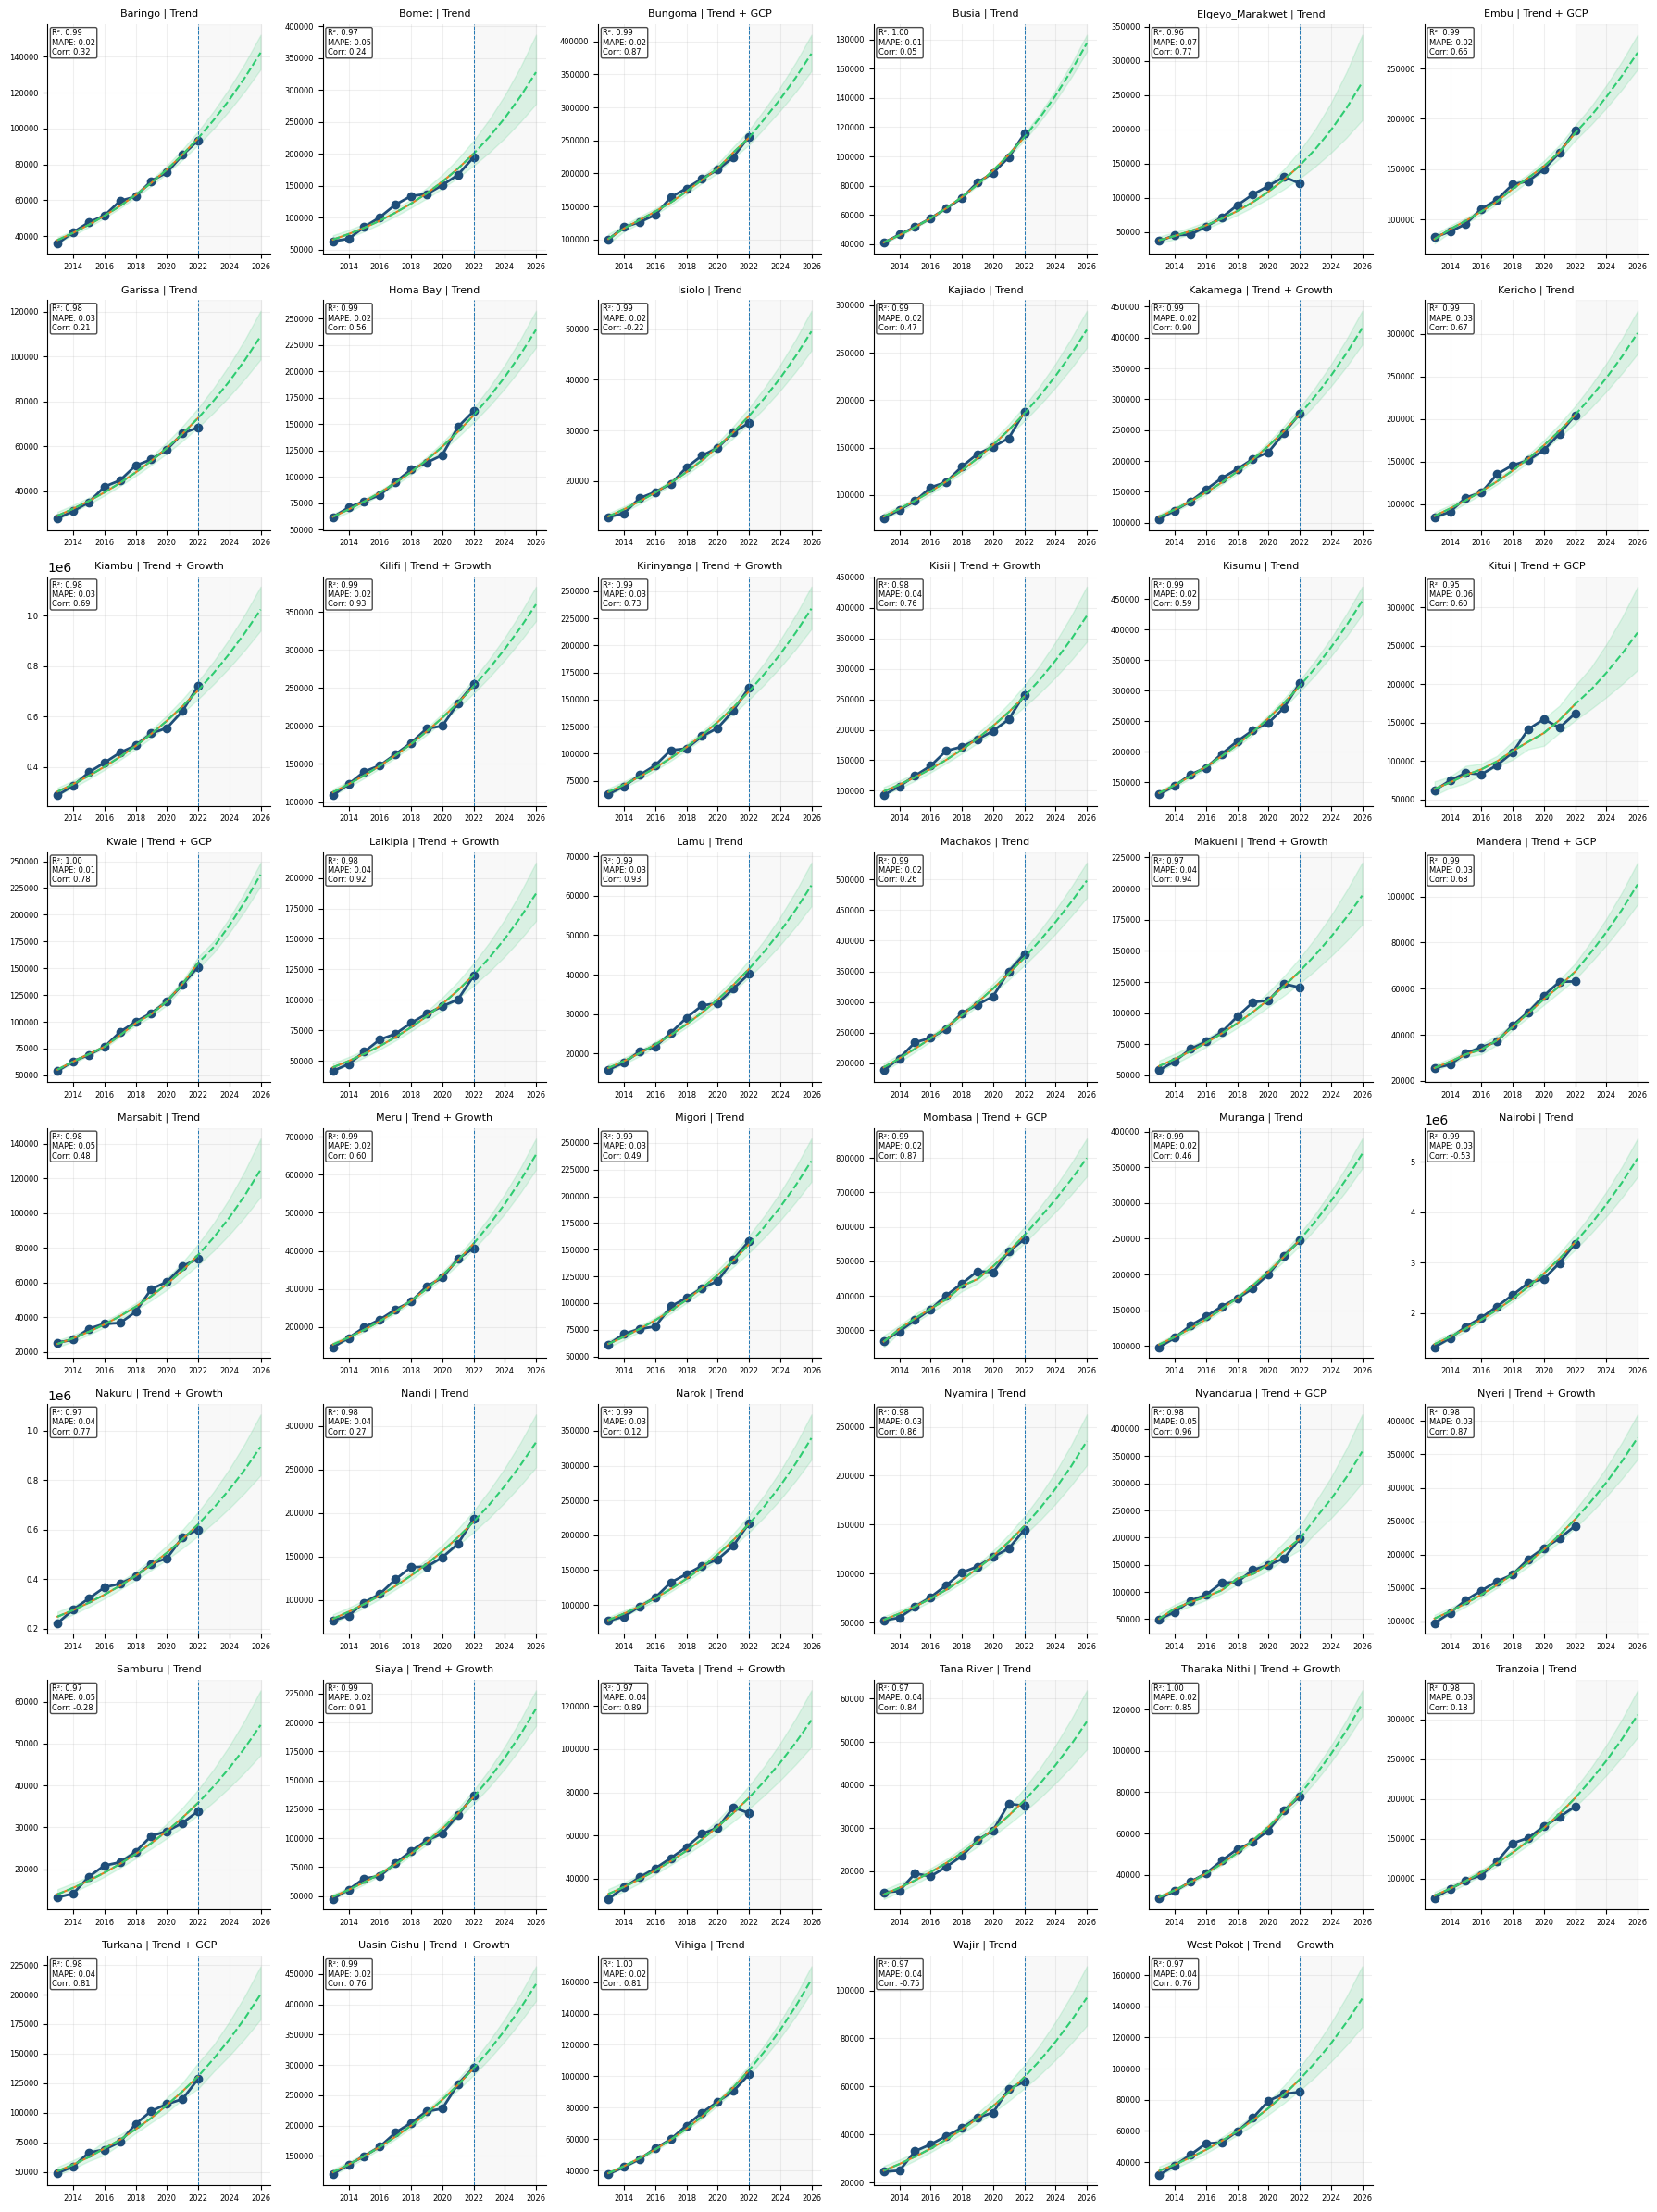

<Figure size 640x480 with 0 Axes>

In [18]:
# --------------------------------------------------
# County OSR dashboard: fitted + forecast + diagnostics
# --------------------------------------------------

df_work = df.copy()

# ensure variables
if "gcp" not in df_work.columns:
    df_work["gcp"] = df_work["gcp_nominal"]

df_work = df_work.dropna(subset=["county","year","osr","gcp"]).copy()
df_work = df_work[(df_work["osr"] > 0) & (df_work["gcp"] > 0)]

df_work["ln_osr"] = np.log(df_work["osr"])
df_work["ln_gcp"] = np.log(df_work["gcp"])

df_work = df_work.sort_values(["county","year"])

counties = sorted(df_work["county"].unique())

# layout
cols = 6
rows = int(np.ceil(len(counties) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 3*rows))
axes = axes.flatten()

# colors
c_actual   = "#1f4e79"
c_fitted   = "#e67e22"
c_forecast = "#2ecc71"
c_band     = "#2ecc71"

title_map = {
    "A_trend_only": "Trend",
    "B_trend_plus_elasticity": "Trend + GCP",
    "C_trend_plus_growth": "Trend + Growth"
}

for i, county in enumerate(counties):

    g = df_work[df_work["county"] == county].copy()
    g = g.sort_values("year")

    if len(g) < 6:
        axes[i].axis("off")
        continue

    g["t"] = np.arange(len(g))

    # pick model
    model_name = final.loc[final["county"] == county, "recommended_model"].values
    if len(model_name) == 0:
        axes[i].axis("off")
        continue
    model_name = model_name[0]

    # estimate
    if model_name == "B_trend_plus_elasticity":
        X = sm.add_constant(g[["t","ln_gcp"]])
    else:
        X = sm.add_constant(g[["t"]])

    model = sm.OLS(g["ln_osr"], X).fit()

    # fitted
    g["fitted"] = np.exp(model.predict(X))

    # diagnostics
    r2 = model.rsquared
    corr = g["ln_osr"].corr(g["ln_gcp"])
    mape = mean_absolute_percentage_error(g["osr"], g["fitted"])

    # forecast horizon
    h = 4
    last_t = g["t"].iloc[-1]

    future = pd.DataFrame({
        "year": np.arange(g["year"].max()+1, g["year"].max()+1+h),
        "t": np.arange(last_t+1, last_t+1+h)
    })

    # extend GCP if needed
    if model_name == "B_trend_plus_elasticity":
        gcp_trend = sm.OLS(g["ln_gcp"], sm.add_constant(g[["t"]])).fit()
        future["ln_gcp"] = gcp_trend.predict(sm.add_constant(future[["t"]]))

    g_all = pd.concat([g, future], ignore_index=True)

    # prediction intervals
    if model_name == "B_trend_plus_elasticity":
        X_all = sm.add_constant(g_all[["t","ln_gcp"]])
    else:
        X_all = sm.add_constant(g_all[["t"]])

    pred = model.get_prediction(X_all).summary_frame(alpha=0.05)

    g_all["pred"] = np.exp(pred["mean"])
    g_all["lower"] = np.exp(pred["mean_ci_lower"])
    g_all["upper"] = np.exp(pred["mean_ci_upper"])

    ax = axes[i]

    # actual
    ax.plot(g["year"], g["osr"], color=c_actual, marker="o", linewidth=2)

    # fitted
    ax.plot(g["year"], g["fitted"], color=c_fitted, linewidth=1.5)

    # forecast
    ax.plot(g_all["year"], g_all["pred"], color=c_forecast, linestyle="--", linewidth=1.5)

    # confidence band
    ax.fill_between(
        g_all["year"],
        g_all["lower"],
        g_all["upper"],
        color=c_band,
        alpha=0.15
    )

    # highlight forecast region
    ax.axvspan(g["year"].max(), g_all["year"].max(), color="grey", alpha=0.05)

    # split line
    ax.axvline(g["year"].max(), linestyle="--", linewidth=0.7)

    # title
    ax.set_title(f"{county} | {title_map.get(model_name, model_name)}", fontsize=8)

    # diagnostics box
    ax.text(
        0.02, 0.98,
        f"R²: {r2:.2f}\nMAPE: {mape:.2f}\nCorr: {corr:.2f}",
        transform=ax.transAxes,
        fontsize=6,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7)
    )

    # styling
    ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=6)

# remove empty panels
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# save
plt.savefig("county_osr_dashboard_final.png", dpi=300)

In [19]:
model_selection.isna().sum()
model_selection["recommended_model"].value_counts()

recommended_model
A_trend_only               24
C_trend_plus_growth        15
B_trend_plus_elasticity     8
Name: count, dtype: int64

## Summary

The results show clear differences in how counties generate and sustain revenue. In most cases, OSR follows a stable trend, reflecting persistence and administrative effort. Only a smaller group of counties shows a meaningful linkage between revenue and the economic base, where GCP improves model performance.

The inclusion of diagnostics within each panel confirms this pattern. High fit combined with weak correlation points to trend-driven revenue, while stronger correlation supports the use of GCP-based terms. Forecast accuracy further reinforces the need for selective modelling.

The framework therefore adopts a simple principle: **trend is the default anchor, while economic variables are introduced only where they are empirically justified**. This ensures that forecasts remain robust, interpretable, and aligned with observed county revenue behaviour.